# Batched Layout Optimisation of a Transmon with Optuna

This notebook turns the single-point Palace eigenmode workflow of
{doc}`palace_eigenmode_qubit_resonator` into a design loop. A transmon's
capacitance pads are swept against three objectives at once:

1. **Land the qubit transition frequency** $f_{01}$ on a target, so the
   qubit sits in its allocated band on a multi-qubit chip.
2. **Maximise the relaxation time** $T_1$ the same solve implies, so the
   qubit is as long-lived as the layout allows.
3. **Minimise the pad footprint**, which is what the chip pays in real estate
   and what a larger qubit spends on coupling and crosstalk.

All three come out of one 3-D eigenmode solve plus the geometry that produced
it, so every trial is an independent Palace run and the loop is embarrassingly
parallel. That is the problem shape [Ray](https://docs.ray.io/) is built for:
the driver below keeps a batch of trials in flight across a Ray cluster, while
[Optuna](https://optuna.readthedocs.io/) proposes each new batch with a
multi-objective (NSGA-II) sampler.

The loss side follows {cite:p}`Savola2023`. The energy participation ratios
$p_i$ of the lossy domains, weighted by their loss tangents, give the
dielectric quality factor

$$
Q_\mathrm{TLS} = \left(\sum_i p_i \tan\delta_i\right)^{-1},
\qquad
T_1^\mathrm{TLS} = \frac{Q_\mathrm{TLS}}{2\pi f_{01}} .
$$

The second relation is why the first two objectives conflict: raising
$Q$ and lowering $f_{01}$ both lengthen $T_1$, and the
geometries that do one usually do the other. So the useful question is not
"what maximises $T_1$" but "what is the best $T_1$ at the
frequency we actually need, for a qubit we can afford to place". The
trade-offs between the three are what the Pareto front at the end of the
notebook maps.

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra for gsim, Optuna and the fANOVA
importance analysis. The Ray backend, if you use it, needs `ray` as well:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models          # add --extra ray for the Ray backend
# or with pip:
pip install "qpdk[models]"
```

The optimisation additionally needs the Palace solver, which is external to
qpdk and normally runs on an HPC cluster. Those cells are written out but not
executed when the notebook is rendered; the trial table is embedded so the
analysis runs anywhere.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

::::{note}
The results below were produced by the driver in this notebook running as a
Slurm job on an HPC cluster, with the meshing on the compute nodes and the
solves inside a Palace Apptainer image. The {ref}`launcher <slurm-launcher>`
at the end of the notebook is the one that submitted it.
::::

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import io
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

import matplotlib

# The same source file is the cluster driver, where there is no display and a
# blocking figure would hang the batch. Rendering inside a kernel keeps the
# interactive backend so the figures appear inline.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import gdsfactory as gf
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import optuna
import pandas as pd
from matplotlib.ticker import NullFormatter

from qpdk import PDK, logger
from qpdk.cells import double_pad_transmon_with_bbox
from qpdk.logger import PLAIN_FORMAT, configure_logger
from qpdk.simulation import SlurmCluster
from qpdk.simulation.fem import single_chip_stack, to_fem_regions
from qpdk.simulation.palace_run import (
    add_domain_energy_postprocessing,
    domain_loss_tangents,
    evaluate_simulation,
    solve,
    verify_port_connectivity,
)
from qpdk.simulation.study import RayRunner, SlurmRunner, run_study
from qpdk.tech import LAYER

PDK.activate()

# This notebook ships with its outputs committed, so keep figures raster:
# matplotlib's SVG embeds a DOCTYPE URL that link checkers follow.
matplotlib_inline.backend_inline.set_matplotlib_formats("png")

## The device and its knobs

The device is the {func}`~qpdk.cells.double_pad_transmon_with_bbox` cell: two
rectangular capacitor pads facing each other across a narrow gap, with the
Josephson junction in that gap. Three layout parameters set both observables:

- **pad width** $w$: the pad extent along the junction gap, which sets
  how much pad edge sits close to the opposite pad.
- **pad height** $h$: the pad extent perpendicular to the gap. This is
  the parameter {cite:p}`Savola2023` found most effective for coherence, since
  it adds shunt capacitance without crowding field into the gap.
- **pad gap** $g$: the island-island separation the junction bridges,
  and the strongest single-parameter lever on the frequency.

The frequency follows from the LC circuit the solve implies,
$f_{01} \approx 1/(2\pi\sqrt{L_J C_\Sigma})$, with the junction held at a
fixed $L_J = 10$ nH. That linearisation is what makes a purely
electromagnetic solve informative about the qubit, and it is the same one the
{doc}`palace_eigenmode_qubit_resonator` notebook uses.

In [3]:
PAD_WIDTH_RANGE = (80.0, 420.0)  # µm, along the junction gap
PAD_HEIGHT_RANGE = (150.0, 650.0)  # µm, perpendicular to it
PAD_GAP_RANGE = (10.0, 160.0)  # µm, island-island separation

# A fixed inductor, so the geometry moves f01 only through C_sigma.
L_JUNCTION = 10e-9  # H
F_TARGET = 4.5e9  # Hz, where the qubit should end up
# How close to the target counts as on-target when picking a geometry.
TOLERANCE_BAND = 0.02
# How much T1 a design may give up to be smaller, when choosing from the band.
T1_SLACK = 0.05

# The study size follows the allocation rather than the other way round, so the
# Slurm launcher at the end of the notebook sets these from the job request.
# One switch for every cell that needs a solver, so a half-set value cannot
# run the demos and then silently skip the study.
RUN_OPTIMIZATION = os.environ.get("QPDK_RUN_OPTIMIZATION") == "1"
if RUN_OPTIMIZATION:
    # The driver's stdout is a Slurm .out file someone will `tail -f`, not a
    # terminal, so drop the colour escapes and the decoration.
    configure_logger(log_format=PLAIN_FORMAT, colorize=False)
MAX_IN_FLIGHT = int(os.environ.get("QPDK_MAX_IN_FLIGHT") or 12)  # trials at once
N_TRIALS = int(os.environ.get("QPDK_N_TRIALS") or 150)  # total trials

In [4]:
# Parametric sweeps hand the cell arbitrary floats, and the lumped port gsim
# builds from the layout needs its width on an even database unit. Snapping the
# geometry to this grid is what keeps an arbitrary sampled point buildable.
LAYOUT_GRID_UM = 0.01


@dataclass(slots=True, frozen=True, kw_only=True)
class Layout:
    """One candidate double-pad transmon geometry.

    Attributes:
        pad_width: Pad extent along the junction gap, in µm.
        pad_height: Pad extent perpendicular to the gap, in µm.
        pad_gap: Island-island separation the junction bridges, in µm.
    """

    pad_width: float
    pad_height: float
    pad_gap: float

    @property
    def pad_size(self) -> tuple[float, float]:
        """Pad size in µm, as the cell expects it."""
        return (self.pad_width, self.pad_height)

    @property
    def footprint_mm2(self) -> float:
        """Metal area of the two pads in mm².

        The qubit's footprint, which is what a chip pays for in real estate and
        what stands in for the coupling and crosstalk a larger qubit invites.
        Only the pads are counted; the etch around them belongs to the ground
        plane and scales with the gap.
        """
        return 2.0 * self.pad_width * self.pad_height / 1e6


@gf.cell
def transmon_sim_layout(pad_size: tuple[float, float], pad_gap: float) -> gf.Component:
    """Transmon pads wrapped in the area the solver meshes.

    Args:
        pad_size: Pad width and height in µm, snapped to a 10 nm grid.
        pad_gap: Island-island gap in µm, snapped to the same grid.

    Returns:
        Component carrying the layout, its ports, and a ``SIM_AREA`` rectangle
        bounding the simulation domain.
    """
    pad_size = tuple(  # ty: ignore[invalid-assignment]
        gf.snap.snap_to_grid(size, grid_factor=LAYOUT_GRID_UM * 1000)
        for size in pad_size
    )
    pad_gap = gf.snap.snap_to_grid(pad_gap, grid_factor=LAYOUT_GRID_UM * 1000)

    c = gf.Component()
    ref = c << double_pad_transmon_with_bbox(pad_size=pad_size, pad_gap=pad_gap)
    c.add_ports(ref.ports)
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(100, 100))
    return c

## From a layout to a simulation directory

Building the simulation is a three-step recipe, wrapped in one function so a
batch can repeat it cheaply:

1. Lay the cell out and convert the PDK's subtractive etch masks into explicit
   conductor, substrate and vacuum regions ({func}`~qpdk.simulation.to_fem_regions`).
2. Give each region a material and a z-extent through the qpdk single-chip
   layer stack ({func}`~qpdk.simulation.single_chip_stack`).
3. Configure the lumped junction port and the eigenmode search, then mesh.

Two details there are easy to get wrong, and both fail quietly:

- **The junction port has to span the pad gap.** The cell's `junction` port
  carries the junction component's own orientation, which is not the axis the
  pads face along. A port on the wrong axis still solves, it just returns modes
  with no junction energy, and the mode identification below would then pick up
  a spurious mode.
- **Domain energy postprocessing is off by default.** gsim writes an empty
  `Domains.Postprocessing.Energy` list, so {func}`~qpdk.simulation.palace_run.add_domain_energy_postprocessing`
  adds it after the config is written. Without it nothing
  reports where the field is sitting, and the loss budget has no inputs.

The result is a self-contained directory. `config.json` plus `palace.msh` is
everything a Palace binary needs, which is what lets a Ray worker on some
other node pick a trial up with no shared state beyond the filesystem.

In [5]:
def build_simulation(
    layout: Layout,
    sim_dir: Path,
    *,
    junction_inductance: float = 10e-9,
    num_modes: int = 3,
    substrate_thickness: float = 200.0,
    vacuum_thickness: float = 200.0,
    mesh_preset: Literal["coarse", "default", "fine"] = "coarse",
) -> Path:
    """Write a self-contained Palace eigenmode directory for ``layout``.

    The result is ``config.json`` plus ``palace.msh``, which is everything a
    Palace binary needs, so the directory can be handed to a worker on another
    node without any further state.

    Args:
        layout: Candidate geometry.
        sim_dir: Directory to write into; created if missing.
        junction_inductance: Linearised junction inductance in H.
        num_modes: Number of eigenmodes to solve for.
        substrate_thickness: Silicon thickness in µm.
        vacuum_thickness: Air height above the chip in µm.
        mesh_preset: Gmsh mesh preset.

    Returns:
        The simulation directory.
    """
    from gsim.palace import EigenmodeSim

    from qpdk import PDK

    # A worker importing this module cold has no PDK active, and the cells
    # cannot resolve their layers without one. Activating is idempotent.
    PDK.activate()

    sim_dir.mkdir(parents=True, exist_ok=True)
    regions = to_fem_regions(transmon_sim_layout(layout.pad_size, layout.pad_gap))
    # The cell's junction port carries the junction component's own orientation,
    # which is not the axis the pads face along. The lumped port has to bridge
    # the two pad edges, so the orientation is set explicitly.
    regions.ports["junction"].orientation = 0.0

    sim = EigenmodeSim()
    sim.set_geometry(regions)
    sim.set_stack(
        single_chip_stack(
            substrate_thickness=substrate_thickness,
            vacuum_thickness=vacuum_thickness,
        )
    )
    sim.set_numerical(order=1, solver_type="MUMPS")
    # resistance=0 overrides gsim's default 50 Ohm port impedance: a linearised
    # junction is purely reactive.
    sim.add_port(
        "junction",
        layer="SUPERCONDUCTOR",
        length=layout.pad_gap + 10.0,
        inductance=junction_inductance,
        resistance=0.0,
    )
    sim.set_eigenmode(target=1e9, num_modes=num_modes)
    sim.set_output_dir(sim_dir)
    sim.mesh(preset=mesh_preset, auto_size=True, cells_per_feature=2)
    sim.write_config()
    add_domain_energy_postprocessing(sim_dir)
    verify_port_connectivity(sim_dir)
    return sim_dir

In [6]:
demo_layout = Layout(pad_width=250.0, pad_height=400.0, pad_gap=15.0)
demo_dir = Path("build/palace_optimization_demo")
# Meshing is Gmsh, which needs GL libraries a docs runner may not have, so it
# is behind the same switch as the solve below rather than running on import.
if RUN_OPTIMIZATION:
    build_simulation(demo_layout, demo_dir)
    logger.info(f"wrote {demo_dir}")

## Running Palace

Palace is invoked as a subprocess against that directory, so how it is
launched is a site detail rather than a property of the workflow:
{func}`~qpdk.simulation.palace_run.palace_command` reads the arrangement from
the environment, covering a `palace` on `PATH`, an Apptainer image on a compute
node, and a wrapper command for the awkward cases.

## Reading a solve back into physics

Palace writes three tables per solve, and each carries a piece of the answer:

- `eig.csv`: the eigenfrequencies and quality factors. With the stack's loss
  tangents in the model, `Q` **is** $Q_\mathrm{TLS}$, so the loss side
  needs no separate simulation.
- `port-EPR.csv`: each lumped port's energy participation, which is what
  identifies the qubit mode among the packaging and ground-plane modes the
  solve also returns. The rule is the **lowest** mode the junction takes part
  in, and picking the largest participation instead is a trap: a higher-order
  mode can carry marginally more junction energy than the fundamental, and
  that near-tie silently returns harmonics at several times the qubit
  frequency.
- `domain-E.csv`: the electric energy in each domain, hence $p_i$
  directly. This is what makes the loss budget legible.

In [7]:
# The demo solve doubles as a smoke check before a batch goes out. The driver
# runs on a single core, so the demo is solved on a single rank: it is a coarse
# mesh on a small layout and does not need more.
if RUN_OPTIMIZATION:
    solve(demo_dir, ranks=1)
    demo_result = evaluate_simulation(demo_dir)
    logger.info(
        f"demo layout: f01 = {demo_result['f01'] / 1e9:.4f} GHz, "
        f"T1 = {demo_result['T1'] * 1e6:.2f} µs, "
        f"Q = {demo_result['quality_factor']:.3e}"
    )

### The loss budget, and what is missing from it

The loss side deserves one check before it is trusted. The stack here has two
dielectric domains: vacuum, which is lossless, and the silicon substrate,
whose loss tangent qpdk takes from low-temperature measurements of the same
material ($\tan\delta_\mathrm{Si} = 2.7\times10^{-6}$). Nothing else in
the model dissipates, so rebuilding
$Q = \left(\sum_i p_i \tan\delta_i\right)^{-1}$ from the reported
participations and those tangents has to reproduce the `Q` Palace reports.

That it does is what licenses reading `Q` as a participation-weighted loss
budget rather than as an opaque solver output.

The caveat it also makes visible is the interesting one. The interfaces that
dominate TLS loss in a real chip, metal-air, metal-substrate and
substrate-air, are nanometres thick and are not resolved by a mesh built for a
millimetre-scale layout. {cite:p}`Savola2023` treats them in 2-D cross-sections
where the layers can be meshed explicitly, and finds the metal-air interface
alone carrying roughly 90 % of the surface participation. So the `Q` here is
the *substrate-limited* one, and since
$Q_\mathrm{TLS} = (\sum_i p_i \tan\delta_i)^{-1}$ it is an upper bound:
every interface the model cannot see adds a term to that sum and can only
lower it. The $T_1$ below is therefore optimistic, and the geometry
dependence it shows is the part that survives without an interface model.

It is worth putting a number on how optimistic. The silicon loss tangent here
is qpdk's measured $2.7\times10^{-6}$, so the substrate term is
$p_\mathrm{sub}\tan\delta_\mathrm{sub} \approx 2.5\times10^{-6}$. The
interface budget {cite:p}`Savola2023` measures for a comparable niobium-on-
silicon process, with the metal-air, metal-substrate and substrate-air layers
included, is $\delta_\mathrm{interfaces} \approx 1.0\times10^{-6}$ to
$5.5\times10^{-6}$. Adding that to the substrate term rather than
assuming it away puts the total loss 1.4x to 3.2x higher, and $Q$ in the
$1\times10^5$ to $3\times10^5$ range instead of $4\times10^5$.
The ordering of the sweep is unaffected; the absolute $T_1$ is not.

This is also why $Q$ here barely responds to the layout while the thesis
reports it moving by tens of percent for the same kind of geometry. The
substrate participation is saturated near 0.92, so the only quantity left
carrying the geometry is the frequency. The interface participations are the
ones that respond to where the metal edges are, and they are exactly what this
mesh does not have.

In [8]:
if RUN_OPTIMIZATION:
    tangents = domain_loss_tangents(demo_dir)
    budget = sum(
        demo_result[f"participation_domain{index}"] * tangent
        for index, tangent in tangents.items()
    )
    logger.info(
        f"1/Q rebuilt from participations {budget:.4e} "
        f"vs reported {1 / demo_result['quality_factor']:.4e}"
    )

In [9]:
def trial_dir_name(layout: Layout) -> str:
    """Return the directory name a trial of ``layout`` is written under.

    Resolved at the sampling grid (:data:`LAYOUT_GRID_UM`) rather than coarser:
    at 0.1 µm two distinct sampled layouts collide on one directory, and two
    array tasks in the same wave would then mesh and solve on top of each other.

    Args:
        layout: Candidate geometry.

    Returns:
        A directory name unique to the geometry at grid resolution.
    """
    return f"w{layout.pad_width:.2f}_h{layout.pad_height:.2f}_g{layout.pad_gap:.2f}"


def evaluate_layout(
    params: dict[str, float],
    run_root: str | Path,
    *,
    ranks: int = 2,
    sim_dir: str | Path | None = None,
    timeout: float = 1800.0,
    **build_settings: Any,
) -> dict[str, Any]:
    """Build, solve and post-process one candidate geometry.

    This is the unit of work a sweep repeats, so it takes and returns plain
    data: everything it learns is either in the return value or on disk under
    ``run_root``, and a caller that dies loses only its own trial.

    Args:
        params: Keyword arguments for :class:`Layout`.
        run_root: Directory trials are written under, one per geometry.
        ranks: MPI ranks to give each solve.
        sim_dir: Directory for this trial. Defaults to a geometry-named
            directory under ``run_root``, which is only safe when trials do not
            run concurrently.
        timeout: Seconds before a solve is abandoned. Size it under the array
            task's wall clock, or Slurm kills the task first and the trial
            reports nothing.
        **build_settings: Forwarded to :func:`build_simulation`.

    Returns:
        The row from :func:`evaluate_simulation`, plus the geometry parameters.
    """
    layout = Layout(**params)
    # Callers running trials concurrently must pass their own directory: two
    # tasks handed the same geometry would otherwise mesh, solve and write
    # results on top of each other, and the interleaved output still parses
    # cleanly. Optuna does re-suggest identical parameter sets, so that is not
    # hypothetical. The geometry-named default is for serial callers.
    sim_dir = Path(sim_dir) if sim_dir else Path(run_root) / trial_dir_name(layout)
    build_simulation(layout, sim_dir, **build_settings)
    solve(sim_dir, ranks=ranks, timeout=timeout)
    # The footprint is a property of the geometry rather than of the solve, but
    # it travels in the same row so a study can use it as an objective.
    return (
        evaluate_simulation(sim_dir) | params | {"footprint_mm2": layout.footprint_mm2}
    )

## Checking that the mode is real

A solve that converges is not the same as a solve that found the device. The
failure to watch for is a lumped port that does not actually touch the metal it
is supposed to bridge: the mesh still validates, the solve still converges, and
every number that comes back is an artifact of the port's own local
capacitance. Two checks separate the two cases, and both are cheap enough to
run before trusting a sweep.

**Port connectivity.** The port's surface has to share mesh nodes with the
conductor. Below, the port rectangle shares four nodes with the metal, which is
what a healthy transmon port looks like; a broken one shares none.

```python
import gmsh

gmsh.initialize()
gmsh.open("palace.msh")
# {'P1': 4} -> the junction port shares 4 nodes with the metal
```

**Inductance scaling.** The qubit mode is an LC mode of the junction, so
doubling the junction inductance has to move it by exactly
$1/\sqrt{2}$ and leave its participation alone. A packaging or
ground-plane mode does not care about the junction at all. Solving the same
geometry twice on the cluster gives

| $L_J$ | $f_{01}$ (GHz) | junction participation |
| --- | --- | --- |
| 10 nH | 2.678243 | -0.3008 |
| 20 nH | 1.894366 | -0.3010 |

a ratio of 0.70732 against the expected 0.70711, or 0.03 % off, with the
participation unchanged in the third digit. That is the mode this notebook is
optimising, not a port artifact.

```python
for factor in (1.0, 2.0):
    build_simulation(geometry, sim_dir, junction_inductance=10e-9 * factor)
    solve(sim_dir, ranks=8)
    print(evaluate_simulation(sim_dir)["f01"])
```

In [10]:
# The site settings live here, and every one of them can be overridden from the
# environment so that a driver script can point the notebook at a real cluster
# without editing it. The defaults are placeholders.
def site(name: str, default: str) -> str:
    """Return a site setting, letting the environment override the default."""
    return os.environ.get(f"QPDK_{name.upper()}") or default


DEFAULT_SETUP = """
module load python 2>/dev/null || true
export UV_CACHE_DIR="$QPDK_SCRATCH/uv-cache"
export UV_PYTHON_INSTALL_DIR="$QPDK_SCRATCH/uv-python"
export PATH="$HOME/.local/bin:$PATH"
"""

# The Palace image, as a compute node sees it. Passed to the trial processes
# through the environment rather than the allocation.
PALACE_SIF = site("sif", "/path/to/palace.sif")

cluster = SlurmCluster(
    # Name every partition the job can run on, not just the fastest: Slurm
    # starts the job wherever it can begin earliest, which usually beats
    # waiting on one busy partition.
    partition=site("partition", "batch"),
    # A shared filesystem visible from every node, where the jobs run and the
    # trial directories are written.
    scratch=site("scratch", "/scratch/$USER/palace-optimization"),
    # Load whatever the site needs before the solver starts. Two things this
    # usually has to cover: a cluster's packaged Python is often older than
    # qpdk's floor, so let uv fetch its own interpreter, and home directories
    # are small and shared, so the caches belong on scratch.
    setup=site("setup", DEFAULT_SETUP),
    # One job per trial, sized by the cores a single solve wants.
    solver_cores=int(site("solver_cores", "8")),
    mem_per_task=site("mem_per_task", "24G"),
    time_limit=site("time_limit", "02:00:00"),
    # Only the Ray arrangement uses these: they size the one allocation it
    # hosts the cluster in. One job per trial is sized on its own instead.
    nodes=int(site("nodes", "2")),
    cores_per_node=int(site("cores_per_node", "40")),
    mem_per_node=site("mem_per_node", "180G"),
    job_name=site("job_name", "qpdk-opt"),
    log_dir=site("log_dir", "slurm-logs"),
    # Empty means "do not emit --account"; many sites have exactly one usable
    # account and reject an explicit one.
    account=site("account", "") or None,
    driver_time_limit=site("driver_time_limit", "24:00:00"),
)

## Running the study

A trial is independent of every other, so the study is just: ask Optuna for a
geometry, evaluate it somewhere, tell Optuna what came back. Only the middle
step depends on where the compute is, and that is the one piece worth
swapping.

{func}`~qpdk.simulation.study.run_study` owns the loop, and a *runner* owns
the "somewhere". Two come with qpdk, differing only in where a trial lands:

- {class}`~qpdk.simulation.study.SlurmRunner` submits one job per trial. A
  small job starts on any node with cores to spare, so the sweep fills
  whatever the cluster has free rather than waiting for a node.
- {class}`~qpdk.simulation.study.RayRunner` dispatches a Ray task per trial,
  for when the study already owns an allocation.

Either way the trial runs in another process, so the runner is given the
evaluator as `module:function` rather than the function itself: the worker
imports it. `evaluate_layout` above is defined in this notebook, which a
compute node cannot import, so a real sweep copies the geometry and
evaluation cells into a module on the shared filesystem and names that.

What it deliberately does *not* do is evaluate fixed batches. A batch can only
advance when its slowest member finishes, so a wave of twelve solves leaves
most of its allocation idle waiting for one large mesh, and the sampler learns
nothing until the whole wave lands. Instead a fixed number of trials stays in
flight: each result is told to the sampler as it arrives, and its slot is
refilled immediately. `max_in_flight` is the only concurrency knob, and it
belongs to the study rather than to the scheduler.

In [11]:
RUN_ROOT = (
    Path(os.path.expandvars(site("scratch", "build"))) / "palace_optimization_trials"
)


def suggest_layout(trial: optuna.Trial) -> None:
    """Ask Optuna for a candidate geometry, recording it on the trial.

    Suggestions land on the layout grid, so a trial's recorded parameters are
    exactly the geometry that was simulated.
    """
    for name, (low, high) in (
        ("pad_width", PAD_WIDTH_RANGE),
        ("pad_height", PAD_HEIGHT_RANGE),
        ("pad_gap", PAD_GAP_RANGE),
    ):
        trial.suggest_float(name, low, high, step=LAYOUT_GRID_UM)


def objectives(row: dict[str, Any]) -> list[float]:
    """Map one solved trial to the three values the study is ranking.

    Args:
        row: A result row from ``evaluate_layout``.

    Returns:
        Relative frequency error, relaxation time, and pad footprint.
    """
    return [
        abs(row["f01"] - F_TARGET) / F_TARGET,
        row["T1"],
        row["footprint_mm2"],
    ]


def make_study() -> optuna.Study:
    """Return the multi-objective study this sweep optimises.

    Returns:
        A study ranking frequency error, coherence and footprint together.
    """
    return optuna.create_study(
        study_name="transmon-layout",
        # Frequency error, then coherence, then footprint.
        directions=["minimize", "maximize", "minimize"],
        # NSGA-II keeps a population of non-dominated trials instead of
        # collapsing the objectives into one score.
        sampler=optuna.samplers.NSGAIISampler(seed=0),
    )


# Where the worker imports `evaluate_layout` from, on the node it lands on.
EVALUATOR = os.environ.get("QPDK_EVALUATOR", "transmon_sweep:evaluate_layout")


def make_runner() -> SlurmRunner | RayRunner:
    """Return the runner the environment selects.

    Returns:
        A Ray runner when ``QPDK_EXECUTOR=ray``, otherwise a Slurm one.
    """
    if os.environ.get("QPDK_EXECUTOR") == "ray":
        return RayRunner(
            run_root=RUN_ROOT, ranks=cluster.solver_cores, evaluator=EVALUATOR
        )
    return SlurmRunner(
        cluster=cluster,
        run_root=RUN_ROOT,
        ranks=cluster.solver_cores,
        evaluator=EVALUATOR,
    )

## Results

The study cell above is skipped when the notebook is rendered; the table it
produced is embedded instead, so everything below runs without a solver.

In [12]:
# Palace sweep results, embedded so the analysis runs without the solver:
# one row per successful trial, with the geometry, the two objectives, and the
# loss diagnostics.
TRIALS_CSV = """\
trial,pad_width,pad_height,pad_gap,f01,T1,quality_factor,junction_participation,footprint_mm2,participation_domain1,participation_domain2
0,266.6,507.6,100.42,4831318805.599,1.327e-05,402702.807552,-0.763765,0.27065,0.91970629,0.08029371
1,265.26,361.83,106.89,5520110030.087,1.161e-05,402715.684669,-0.768908,0.19196,0.91968866,0.08031134
2,228.78,595.89,154.55,5095841207.160001,1.258e-05,402683.31006,-0.823952,0.27266,0.91975317,0.08024683
3,210.37,545.87,89.33,4718810212.447,1.359e-05,402802.21264,-0.741356,0.22967,0.91948245,0.08051755
4,273.14,612.8,20.65,2570014294.213,2.497e-05,403178.065762,0.386827,0.33476,0.91863015,0.08136985
5,109.62,160.1,134.9,8785334613.002,7.29e-06,402638.134854,-0.807621,0.0351,0.91992082,0.08007918
6,344.58,585.01,156.8,4869768604.125,1.317e-05,402948.005737,-0.824228,0.40317,0.91914991,0.08085009
7,351.72,380.74,127.08,5330365007.625999,1.203e-05,402823.320353,0.796132,0.26783,0.91944047,0.08055953
8,120.21,469.96,31.5,3796524661.685,1.688e-05,402712.469995,0.487026,0.11299,0.91969044,0.08030956
9,401.19,410.92,72.2,4473217264.236,1.433e-05,402698.13979,-0.691211,0.32971,0.91972398,0.08027602
10,169.95,537.12,78.42,4719575748.837,1.358e-05,402707.594932,-0.715379,0.18257,0.91969953,0.08030047
11,273.27,159.39,102.65,6872998507.028,9.33e-06,402719.911325,-0.759449,0.08711,0.91967888,0.08032112
12,288.11,458.47,151.57,5392425966.571,1.189e-05,402702.594711,-0.820061,0.26418,0.91970493,0.08029507
13,311.82,329.75,75.55,5080407958.6,1.262e-05,402899.99869,0.702707,0.20565,0.91925573,0.08074427
14,317.2,180.11,110.02,6578349841.757,9.75e-06,402827.619849,0.775896,0.11426,0.91942395,0.08057605
15,308.02,255.19,29.34,4163300396.166,1.539e-05,402685.132348,-0.484043,0.15721,0.91975436,0.08024564
16,187.24,331.85,95.53,5868667389.806,1.092e-05,402692.653149,0.749724,0.12427,0.91973315,0.08026685
17,229.12,644.19,25.3,2814519912.294,2.277e-05,402689.315821,-0.444576,0.29519,0.9197454,0.0802546
18,151.02,230.65,107.97,7051945971.059,9.09e-06,402703.007921,-0.770812,0.06967,0.91974222,0.08025778
19,166.12,383.16,46.66,4630106346.143,1.384e-05,402708.962327,-0.595037,0.1273,0.91967906,0.08032094
20,134.05,205.18,108.45,7531042899.276999,8.52e-06,402959.936514,-0.772526,0.05501,0.91913238,0.08086762
21,126.98,248.29,65.31,6263957252.593,1.024e-05,402836.797416,-0.668728,0.06306,0.91940285,0.08059715
22,359.14,198.55,135.7,6412397580.007,9.99e-06,402671.318062,-0.803913,0.14261,0.91977451,0.08022549
23,112.67,638.23,80.3,4703081786.164,1.363e-05,402701.652817,-0.723651,0.14382,0.9197184,0.0802816
24,412.1,452.42,120.89,4859310353.605,1.319e-05,402651.746647,-0.785921,0.37288,0.91982236,0.08017764
25,93.32,291.4,28.03,4651026053.243,1.378e-05,402737.273481,0.464375,0.05439,0.91963766,0.08036234
26,180.69,209.36,57.7,5996865568.599,1.07e-05,403056.676162,0.640897,0.07566,0.91890474,0.08109526
27,220.85,182.07,113.87,7122005255.882999,9e-06,402837.076422,0.779346,0.08042,0.91941102,0.08058898
28,272.65,282.69,88.49,5690858726.854,1.126e-05,402621.248369,-0.736279,0.15415,0.91989108,0.08010892
29,111.94,437.97,149.4,6370317559.183001,1.007e-05,402889.871338,0.823943,0.09805,0.91928449,0.08071551
30,188.31,483.71,29.77,3544376023.786,1.808e-05,402700.601483,0.496322,0.18217,0.9197119,0.0802881
31,323.55,294.7,37.48,4242953053.966999,1.51e-05,402653.878866,0.539787,0.1907,0.9198265,0.0801735
32,279.42,160.05,134.34,7171419507.381,8.94e-06,402644.749921,-0.803725,0.08944,0.91983434,0.08016566
33,81.59,488.91,50.5,4738102441.876,1.354e-05,403153.741114,-0.605842,0.07978,0.91868014,0.08131986
34,329.97,631.1,47.31,3500588224.25,1.831e-05,402699.065288,0.603918,0.41649,0.91972202,0.08027798
35,275.89,446.02,95.84,4960627715.352,1.292e-05,402691.324829,-0.750432,0.2461,0.91973505,0.08026495
36,155.84,626.38,77.07,4455676455.204,1.439e-05,402944.336634,0.709972,0.19523,0.91915282,0.08084718
37,367.78,499.74,54.61,3916678478.498,1.636e-05,402719.578417,-0.630715,0.36759,0.91967332,0.08032668
38,356.69,348.25,142.17,5590303002.118999,1.146e-05,402676.263414,0.810512,0.24843,0.91977713,0.08022287
39,277.63,590.87,113.88,4660833083.696,1.375e-05,402724.55257,0.778913,0.32809,0.9196595,0.0803405
40,326.59,400.66,153.42,5507028299.842,1.164e-05,402673.036068,0.822005,0.2617,0.9197763,0.0802237
41,298.96,361.93,100.96,5325974789.892,1.203e-05,402730.848248,0.756441,0.21641,0.91963016,0.08036984
42,86.52,300.79,109.03,7146731479.563,8.97e-06,402941.587523,0.776485,0.05205,0.91919188,0.08080812
43,178.62,459.01,74.31,4910096726.999,1.305e-05,402711.408778,0.700182,0.16398,0.9196891,0.0803109
44,126.06,299.14,95.5,6498749999.832999,9.86e-06,402696.26078,0.750038,0.07542,0.91969535,0.08030465
45,280.9,437.16,107.98,5128156115.125,1.25e-05,402676.593802,-0.772307,0.2456,0.91977313,0.08022687
46,301.72,365.71,144.49,5690910203.48,1.126e-05,402702.543969,0.814236,0.22068,0.91971777,0.08028223
47,204.97,367.93,143.79,6073063893.279,1.055e-05,402653.291346,0.814452,0.15083,0.91983434,0.08016566
48,354.11,501.95,25.03,2968006733.015,2.159e-05,402704.532696,-0.442016,0.35549,0.91970721,0.08029279
49,392.63,507.12,159.83,5009216981.615001,1.28e-05,402757.998326,-0.828001,0.39822,0.91958817,0.08041183
50,401.19,160.05,72.2,5827816949.044001,1.1e-05,402808.082808,-0.684147,0.12842,0.91947138,0.08052862
51,112.67,638.23,32.41,3380025977.655,1.897e-05,402779.178544,0.49936,0.14382,0.9195371,0.0804629
52,111.94,446.02,140.22,6243650642.335,1.027e-05,402698.877026,-0.816843,0.09985,0.91972923,0.08027077
53,273.27,159.39,34.37,5141456888.749001,1.248e-05,403167.921528,-0.506166,0.08711,0.91865544,0.08134456
54,289.29,211.91,137.2,6655121877.221,9.63e-06,402660.391178,-0.807212,0.12261,0.91983282,0.08016718
55,273.14,612.8,20.65,2570014294.306,2.497e-05,403176.960891,0.386827,0.33476,0.91863015,0.08136985
56,359.14,553.66,29.34,3058515510.142,2.095e-05,402694.182467,-0.490394,0.39768,0.91972768,0.08027232
57,111.94,437.97,95.37,5743399083.632,1.116e-05,402713.780143,-0.749798,0.09805,0.91969383,0.08030617
58,218.44,483.71,20.37,2868516276.884,2.236e-05,403020.22938,-0.380388,0.21132,0.91898721,0.08101279
59,298.96,498.72,78.03,4484461940.971,1.429e-05,402707.86402,-0.712434,0.29819,0.91970267,0.08029733
60,93.32,511.03,28.03,3623781408.656,1.769e-05,402700.556717,-0.470876,0.09538,0.91972325,0.08027675
61,210.37,255.19,89.33,6175766172.654,1.038e-05,402777.622287,-0.738775,0.10737,0.91955496,0.08044504
62,180.69,209.36,139.96,7409754164.063,8.65e-06,402655.136811,0.814938,0.07566,0.91981957,0.08018043
63,411.68,577.91,65.31,3842930055.146,1.668e-05,402744.72809,0.673672,0.47583,0.91961602,0.08038398
64,412.1,294.7,120.89,5513872726.617,1.162e-05,402658.063658,0.786058,0.24289,0.91981023,0.08018977
65,83.98,488.91,64.0,5102780042.702001,1.256e-05,402740.650496,0.667065,0.08212,0.91962852,0.08037148
66,328.2,638.23,80.3,4079733452.154,1.571e-05,402828.414459,-0.721755,0.41893,0.91942849,0.08057151
67,301.72,365.71,144.49,5690910203.226,1.126e-05,402698.410783,0.814236,0.22068,0.91971777,0.08028223
68,109.62,160.1,134.9,8785334618.592,7.29e-06,402612.635024,-0.807621,0.0351,0.91992082,0.08007918
69,93.32,235.81,28.03,4987417730.507,1.285e-05,402809.607346,-0.458766,0.04401,0.91946719,0.08053281
70,367.78,410.52,18.15,2827059581.273,2.267e-05,402763.724356,0.364267,0.30196,0.91956915,0.08043085
71,272.65,282.69,88.49,5690858727.358,1.126e-05,402623.591562,-0.736279,0.15415,0.91989108,0.08010892
72,229.12,507.6,40.0,3785322601.44,1.693e-05,402744.898589,0.565056,0.2326,0.91961092,0.08038908
73,86.29,469.96,134.34,6307678215.96,1.016e-05,402844.168678,0.806719,0.08111,0.91939962,0.08060038
74,86.52,546.85,109.03,5647654883.665,1.136e-05,402938.844141,-0.77616,0.09463,0.91918443,0.08081557
75,166.12,383.16,75.55,5332591103.075,1.202e-05,402682.783776,-0.703157,0.1273,0.91975818,0.08024182
76,392.63,507.12,95.84,4494431466.998,1.427e-05,402874.111622,-0.749331,0.39822,0.91931989,0.08068011
77,156.13,322.67,80.3,5846666967.517,1.097e-05,402924.571678,0.722039,0.10076,0.91921708,0.08078292
78,120.21,469.96,149.22,6118638041.828,1.048e-05,402734.265665,-0.823335,0.11299,0.91964639,0.08035361
79,187.24,331.85,28.03,3981318235.658,1.61e-05,402677.961904,-0.46589,0.12427,0.91976841,0.08023159
80,319.5,182.07,113.87,6564252070.823,9.76e-06,402665.447638,0.777219,0.11634,0.91979308,0.08020692
81,155.84,205.18,14.77,3673812522.122,1.746e-05,402956.17449,-0.28887,0.06395,0.91913354,0.08086646
82,326.59,400.66,153.42,5507028300.016,1.164e-05,402673.188547,0.822005,0.2617,0.9197763,0.0802237
83,135.99,460.74,143.79,5985316124.735001,1.071e-05,402670.689882,0.815207,0.12531,0.91978678,0.08021322
84,277.63,438.62,45.68,4039191541.032,1.587e-05,402698.979824,-0.588081,0.24355,0.91971843,0.08028157
85,397.64,469.96,134.9,4932321556.814,1.3e-05,402829.043092,0.802592,0.37375,0.91942697,0.08057303
86,288.75,294.7,90.35,5596667883.189,1.145e-05,402774.281769,-0.741904,0.17019,0.91954727,0.08045273
87,93.32,444.96,28.03,3855388420.179,1.662e-05,402721.718868,0.46803,0.08305,0.91965916,0.08034084
88,328.24,361.93,149.4,5680638135.822,1.128e-05,402698.282364,0.821001,0.2376,0.91972165,0.08027835
89,311.82,329.75,75.55,5080407958.564,1.262e-05,402903.086811,0.702707,0.20565,0.91925573,0.08074427
90,308.02,255.19,56.79,5121604072.882999,1.252e-05,402866.30147,0.641105,0.15721,0.91934715,0.08065285
91,323.55,294.7,69.73,5139960135.51,1.247e-05,402708.964778,0.691566,0.1907,0.91969629,0.08030371
92,317.2,254.92,88.49,5684656270.273,1.128e-05,402726.408686,0.735458,0.16172,0.91966087,0.08033913
93,120.21,243.09,31.5,4956874839.462999,1.293e-05,402682.086745,-0.474397,0.05844,0.91975527,0.08024473
94,401.09,291.4,120.94,5573252573.622,1.15e-05,402720.615706,-0.784314,0.23376,0.91967318,0.08032682
95,323.55,626.38,77.07,4064639729.499999,1.578e-05,402941.17225,-0.709511,0.40533,0.91916682,0.08083318
96,246.76,160.1,44.11,5649886214.983,1.135e-05,403025.16056,0.560038,0.07901,0.91898219,0.08101781
97,210.37,282.69,89.33,5959155841.158,1.075e-05,402676.638158,-0.740871,0.11894,0.91977134,0.08022866
98,166.48,179.01,75.16,6893161643.993,9.3e-06,402666.515903,-0.696298,0.0596,0.91976658,0.08023342
99,186.01,458.47,114.45,5445975876.299,1.177e-05,402870.099844,-0.78118,0.17056,0.91932515,0.08067485
100,208.43,638.23,134.9,4894614754.756,1.31e-05,402857.553265,0.804804,0.26605,0.91936508,0.08063492
101,359.14,553.66,29.34,3058515510.102,2.095e-05,402696.254573,-0.490394,0.39768,0.91972768,0.08027232
102,141.06,230.65,28.03,4739469236.921,1.352e-05,402745.985426,0.469222,0.06507,0.9196194,0.0803806
103,109.62,577.91,13.7,2407652825.254,2.664e-05,403075.127607,0.281134,0.1267,0.91885532,0.08114468
104,102.86,459.01,111.91,5934713593.785,1.08e-05,402836.257896,-0.776582,0.09443,0.91941486,0.08058514
105,155.84,507.6,100.42,5223789397.297999,1.226e-05,402529.413762,0.763156,0.15821,0.92010902,0.07989098
106,166.12,383.16,46.66,4630106346.306999,1.384e-05,402715.727995,-0.595037,0.1273,0.91967906,0.08032094
107,155.84,438.62,78.05,5198964123.469999,1.234e-05,403056.120125,0.713608,0.13671,0.91891172,0.08108828
108,93.32,235.81,28.03,4987417730.676001,1.285e-05,402809.922501,-0.458766,0.04401,0.91946719,0.08053281
109,218.44,418.29,144.5,5747637142.739,1.115e-05,402828.563739,-0.815216,0.18274,0.91942416,0.08057584
110,126.98,248.29,75.16,6504285491.313999,9.85e-06,402636.813423,-0.699588,0.06306,0.91987473,0.08012527
111,416.72,258.45,109.46,5607236324.597,1.143e-05,402622.189198,-0.773672,0.2154,0.91989905,0.08010095
112,169.53,444.96,13.09,2472792969.675,2.592e-05,402728.018064,0.261563,0.15087,0.91964516,0.08035484
113,188.31,529.19,29.77,3420228179.591,1.874e-05,402700.312078,-0.49878,0.1993,0.91971409,0.08028591
114,188.8,444.96,28.03,3568543739.89,1.796e-05,402708.216419,0.46919,0.16802,0.91969491,0.08030509
115,401.19,410.92,67.52,4397806523.751,1.457e-05,402676.094468,-0.681187,0.32971,0.91977169,0.08022831
116,280.03,507.12,29.34,3259800022.798,1.966e-05,402712.357709,-0.489482,0.28402,0.91969018,0.08030982
117,188.31,483.71,29.77,3544376023.806,1.808e-05,402704.078235,0.496322,0.18217,0.9197119,0.0802881
118,362.56,464.49,109.03,4822114565.655,1.33e-05,402820.607354,0.773822,0.33681,0.91944469,0.08055531
119,376.7,286.77,28.03,3789469819.883,1.691e-05,402733.657907,-0.469871,0.21605,0.91963238,0.08036762
120,351.34,626.38,37.84,3198570176.2,2.004e-05,402711.662467,-0.548256,0.44014,0.91969458,0.08030542
121,401.19,626.4,134.9,4494655900.598,1.427e-05,403000.789624,-0.802578,0.50261,0.91903063,0.08096937
122,313.75,257.75,134.9,6181730164.115,1.037e-05,402826.82029,-0.804615,0.16174,0.91942903,0.08057097
123,120.21,499.74,54.61,4562354241.468,1.406e-05,402994.544383,-0.630855,0.12015,0.91904787,0.08095213
124,120.21,501.95,31.5,3676762101.018,1.745e-05,403044.442924,0.488979,0.12068,0.91893072,0.08106928
125,93.32,469.96,28.03,3775639027.198,1.698e-05,402731.476443,-0.468755,0.08771,0.91964745,0.08035255
126,402.11,515.43,48.09,3697096481.963,1.735e-05,403070.501361,0.607655,0.41452,0.91887492,0.08112508
127,229.12,507.6,41.99,3809369207.568,1.682e-05,402693.563711,-0.563071,0.2326,0.91973275,0.08026725
128,354.11,160.1,25.03,4365764550.798,1.468e-05,402678.627627,0.429885,0.11339,0.91976239,0.08023761
129,83.98,488.91,64.0,5102780042.325999,1.256e-05,402740.274824,0.667065,0.08212,0.91962852,0.08037148
130,256.19,638.23,134.34,4744289696.683001,1.351e-05,402708.697533,0.803345,0.32702,0.91969812,0.08030188
131,88.72,507.12,28.03,3652040574.769,1.756e-05,402877.243137,-0.472915,0.08998,0.91932361,0.08067639
132,180.69,209.36,41.12,5419214429.483,1.182e-05,402631.917938,-0.549865,0.07566,0.91988674,0.08011326
133,93.32,444.96,28.03,3855388420.27,1.662e-05,402724.771816,0.46803,0.08305,0.91965916,0.08034084
134,86.52,362.34,66.12,5828668888.202001,1.1e-05,402709.871783,0.673452,0.0627,0.9197087,0.0802913
135,367.78,381.79,51.64,4227925368.407,1.516e-05,402693.850442,-0.615229,0.28083,0.91973242,0.08026758
136,279.51,294.7,18.15,3331899938.446,1.923e-05,402669.493956,0.363618,0.16474,0.91978738,0.08021262
137,266.6,507.6,50.5,3980646657.191,1.61e-05,402758.189866,0.609217,0.27065,0.91959218,0.08040782
138,373.71,208.76,29.34,4276654858.67,1.499e-05,402727.089845,-0.473666,0.15603,0.91965567,0.08034433
139,93.32,408.69,29.81,4143994163.24,1.547e-05,402771.720291,-0.486216,0.07628,0.91956911,0.08043089
140,308.02,577.91,29.34,3072420041.827,2.087e-05,402841.114901,0.489061,0.35602,0.91939472,0.08060528
141,93.32,243.09,31.5,5157362890.226,1.243e-05,402689.441614,-0.479488,0.04537,0.91972517,0.08027483
142,411.68,248.29,65.31,5064999852.348001,1.265e-05,402726.06711,0.670583,0.20443,0.9196603,0.0803397
143,218.44,483.71,117.53,5236677227.462,1.224e-05,402672.000278,0.786289,0.21132,0.91977231,0.08022769
144,359.14,483.71,69.41,4288750617.22,1.494e-05,402689.29161,0.688975,0.34744,0.91974098,0.08025902
145,367.78,159.39,94.81,6314472242.13,1.015e-05,402661.692772,-0.745556,0.11724,0.91979386,0.08020614
146,210.37,545.87,37.49,3584390032.054,1.788e-05,402710.954709,-0.544253,0.22967,0.91969514,0.08030486
147,218.44,209.36,20.37,3913066370.754,1.638e-05,402728.956248,0.367206,0.09147,0.91965259,0.08034741
148,120.21,612.8,31.5,3389646597.537,1.891e-05,402733.419681,-0.490725,0.14733,0.91963926,0.08036074
149,308.02,222.42,20.37,3699791978.246,1.732e-05,402734.962446,-0.370477,0.13702,0.91963835,0.08036165
"""


if RUN_OPTIMIZATION:
    study = make_study()
    rows = run_study(
        study,
        make_runner(),
        suggest=suggest_layout,
        objectives=objectives,
        n_trials=N_TRIALS,
        max_in_flight=MAX_IN_FLIGHT,
    )
    trials = pd.DataFrame(rows)
    trials.to_csv(os.environ.get("QPDK_TRIALS_CSV", "trials.csv"), index=False)
else:
    trials = pd.read_csv(io.StringIO(TRIALS_CSV))
    study = None

trials["f01_ghz"] = trials["f01"] / 1e9
trials["T1_us"] = trials["T1"] * 1e6
logger.info(f"{len(trials)} successful trials")
trials[
    [
        "f01_ghz",
        "T1_us",
        "footprint_mm2",
        "quality_factor",
        "pad_width",
        "pad_height",
        "pad_gap",
    ]
].describe()

2026-09-23 01:07:02.114 | INFO     | __main__:<module>:177 - 150 successful trials


,f01_ghz,T1_us,footprint_mm2,quality_factor,pad_width,pad_height,pad_gap
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,4.924548,13.914067,0.188391,402767.616868,238.297533,397.268800,77.232000
std,1.230430,3.829189,0.110199,126.397468,103.243858,142.301672,43.555399
min,2.407653,7.290000,0.035100,402529.413762,81.590000,159.390000,13.090000
25%,3.932671,11.260000,0.096048,402691.656909,143.550000,264.510000,31.500000
50%,4.958751,12.925000,0.159965,402717.653206,229.120000,414.605000,75.355000
75%,5.690859,16.295000,0.258383,402827.419959,323.550000,505.827500,111.437500
max,8.785335,26.640000,0.502610,403178.065762,416.720000,644.190000,159.830000


### What the sweep found

Coherence and frequency trade against each other in a way that is worth
looking at directly. Plotted against each other, the trials trace out a band
that runs from high frequency with short $T_1$ down to low frequency
with long $T_1$, with the target frequency cutting across it. That slope
is the $1/f_{01}$ in
$T_1 = Q_\mathrm{TLS}/(2\pi f_{01})$ doing the work: the quality factor
is nearly flat, because the substrate participation barely moves with the
planar geometry.

The footprint is a different story. Colour the same trials by it and the
geometry space is full of designs that reach the same frequency at very
different sizes, which is where the interesting trade-off lives: the band
within the target band spans a factor of four in pad area, from 0.12 to
0.50 mm².

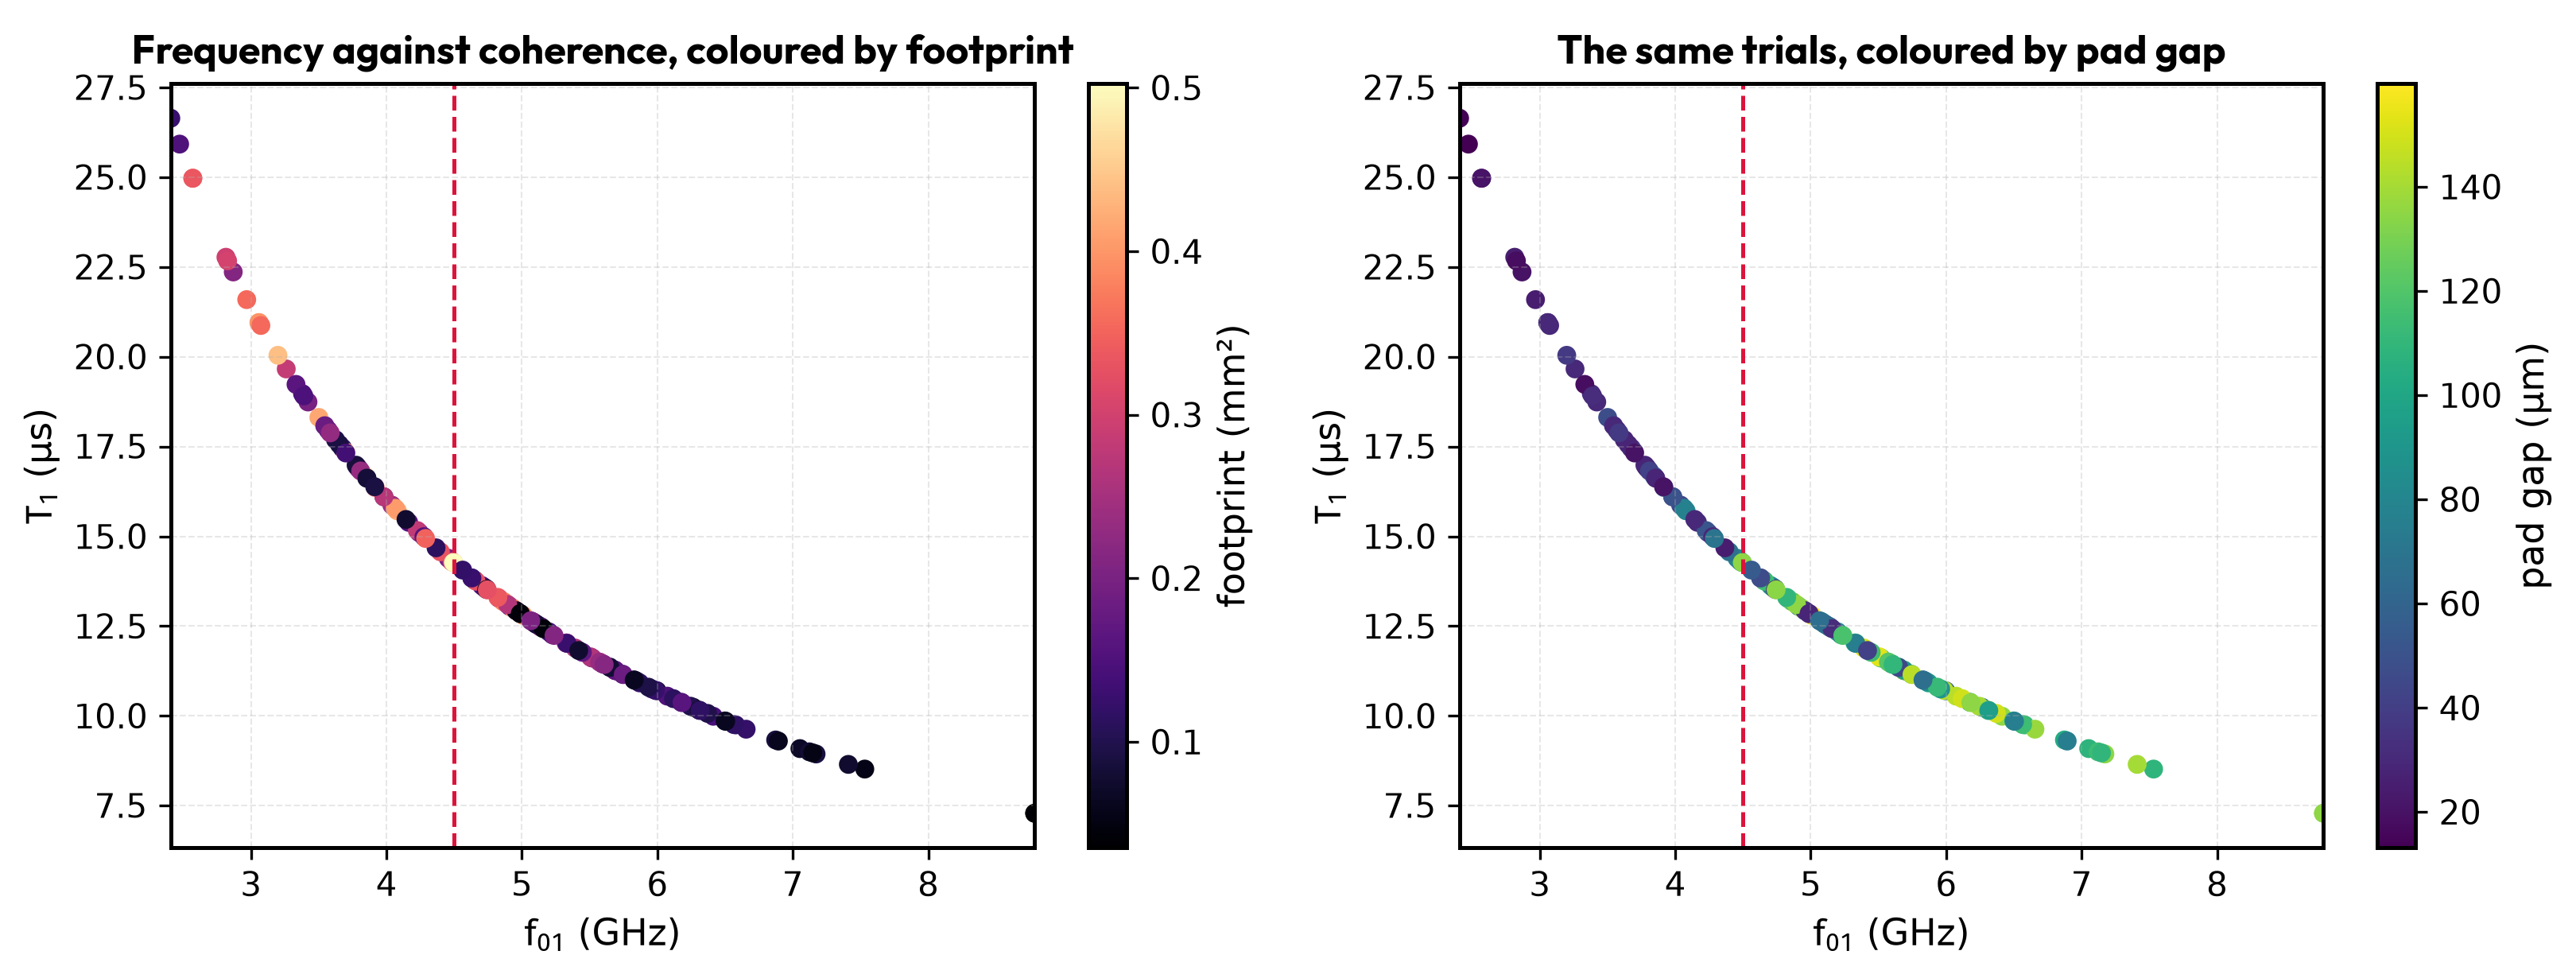

In [13]:
frames = {
    "pad_width": (PAD_WIDTH_RANGE, "pad width (µm)"),
    "pad_height": (PAD_HEIGHT_RANGE, "pad height (µm)"),
    "pad_gap": (PAD_GAP_RANGE, "pad gap (µm)"),
}
PARAMETERS = list(frames)


def pareto_mask(values: np.ndarray) -> np.ndarray:
    """Return a mask of the non-dominated rows of ``values`` (all minimised)."""
    keep = np.ones(len(values), dtype=bool)
    for i, candidate in enumerate(values):
        if not keep[i]:
            continue
        dominated = np.all(values <= candidate, axis=1) & np.any(
            values < candidate, axis=1
        )
        if dominated.any():
            keep[i] = False
    return keep


# All three objectives in the minimisation convention pareto_mask expects:
# frequency error, negative T1, footprint.
objectives = np.column_stack([
    np.abs(trials["f01_ghz"] - F_TARGET / 1e9),
    -trials["T1_us"],
    trials["footprint_mm2"],
])
on_front = pareto_mask(objectives)
target_ghz = F_TARGET / 1e9

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

scatter = axes[0].scatter(
    trials["f01_ghz"],
    trials["T1_us"],
    c=trials["footprint_mm2"],
    cmap="magma",
    s=22,
)
axes[0].axvline(target_ghz, color="crimson", ls="--", lw=1.2)
axes[0].set_xlabel("$f_{01}$ (GHz)")
axes[0].set_ylabel("$T_1$ (µs)")
axes[0].set_title("Frequency against coherence, coloured by footprint")
fig.colorbar(scatter, ax=axes[0], label="footprint (mm²)")

scatter = axes[1].scatter(
    trials["f01_ghz"],
    trials["T1_us"],
    c=trials["pad_gap"],
    cmap="viridis",
    s=22,
)
axes[1].axvline(target_ghz, color="crimson", ls="--", lw=1.2)
axes[1].set_xlabel("$f_{01}$ (GHz)")
axes[1].set_ylabel("$T_1$ (µs)")
axes[1].set_title("The same trials, coloured by pad gap")
fig.colorbar(scatter, ax=axes[1], label="pad gap (µm)")

fig.tight_layout()
plt.show()
plt.close(fig)

### The Pareto front

A trial is *dominated* if another trial beats it on all three objectives. The
non-dominated trials form the Pareto front: the set a designer should actually
be choosing from. Optuna tracks it itself for a multi-objective study, so
`study.best_trials` is the same set.

Three objectives do not fit on one axis pair, so the two panels below project
the same front twice. Against frequency and coherence the front is the two
familiar branches, and the shaded band is the design requirement. Against
coherence and footprint the front shows what the requirement costs: the
designs on the front that are usable span the full footprint range, and the
cheap end of it gives up only a few percent of $T_1$.

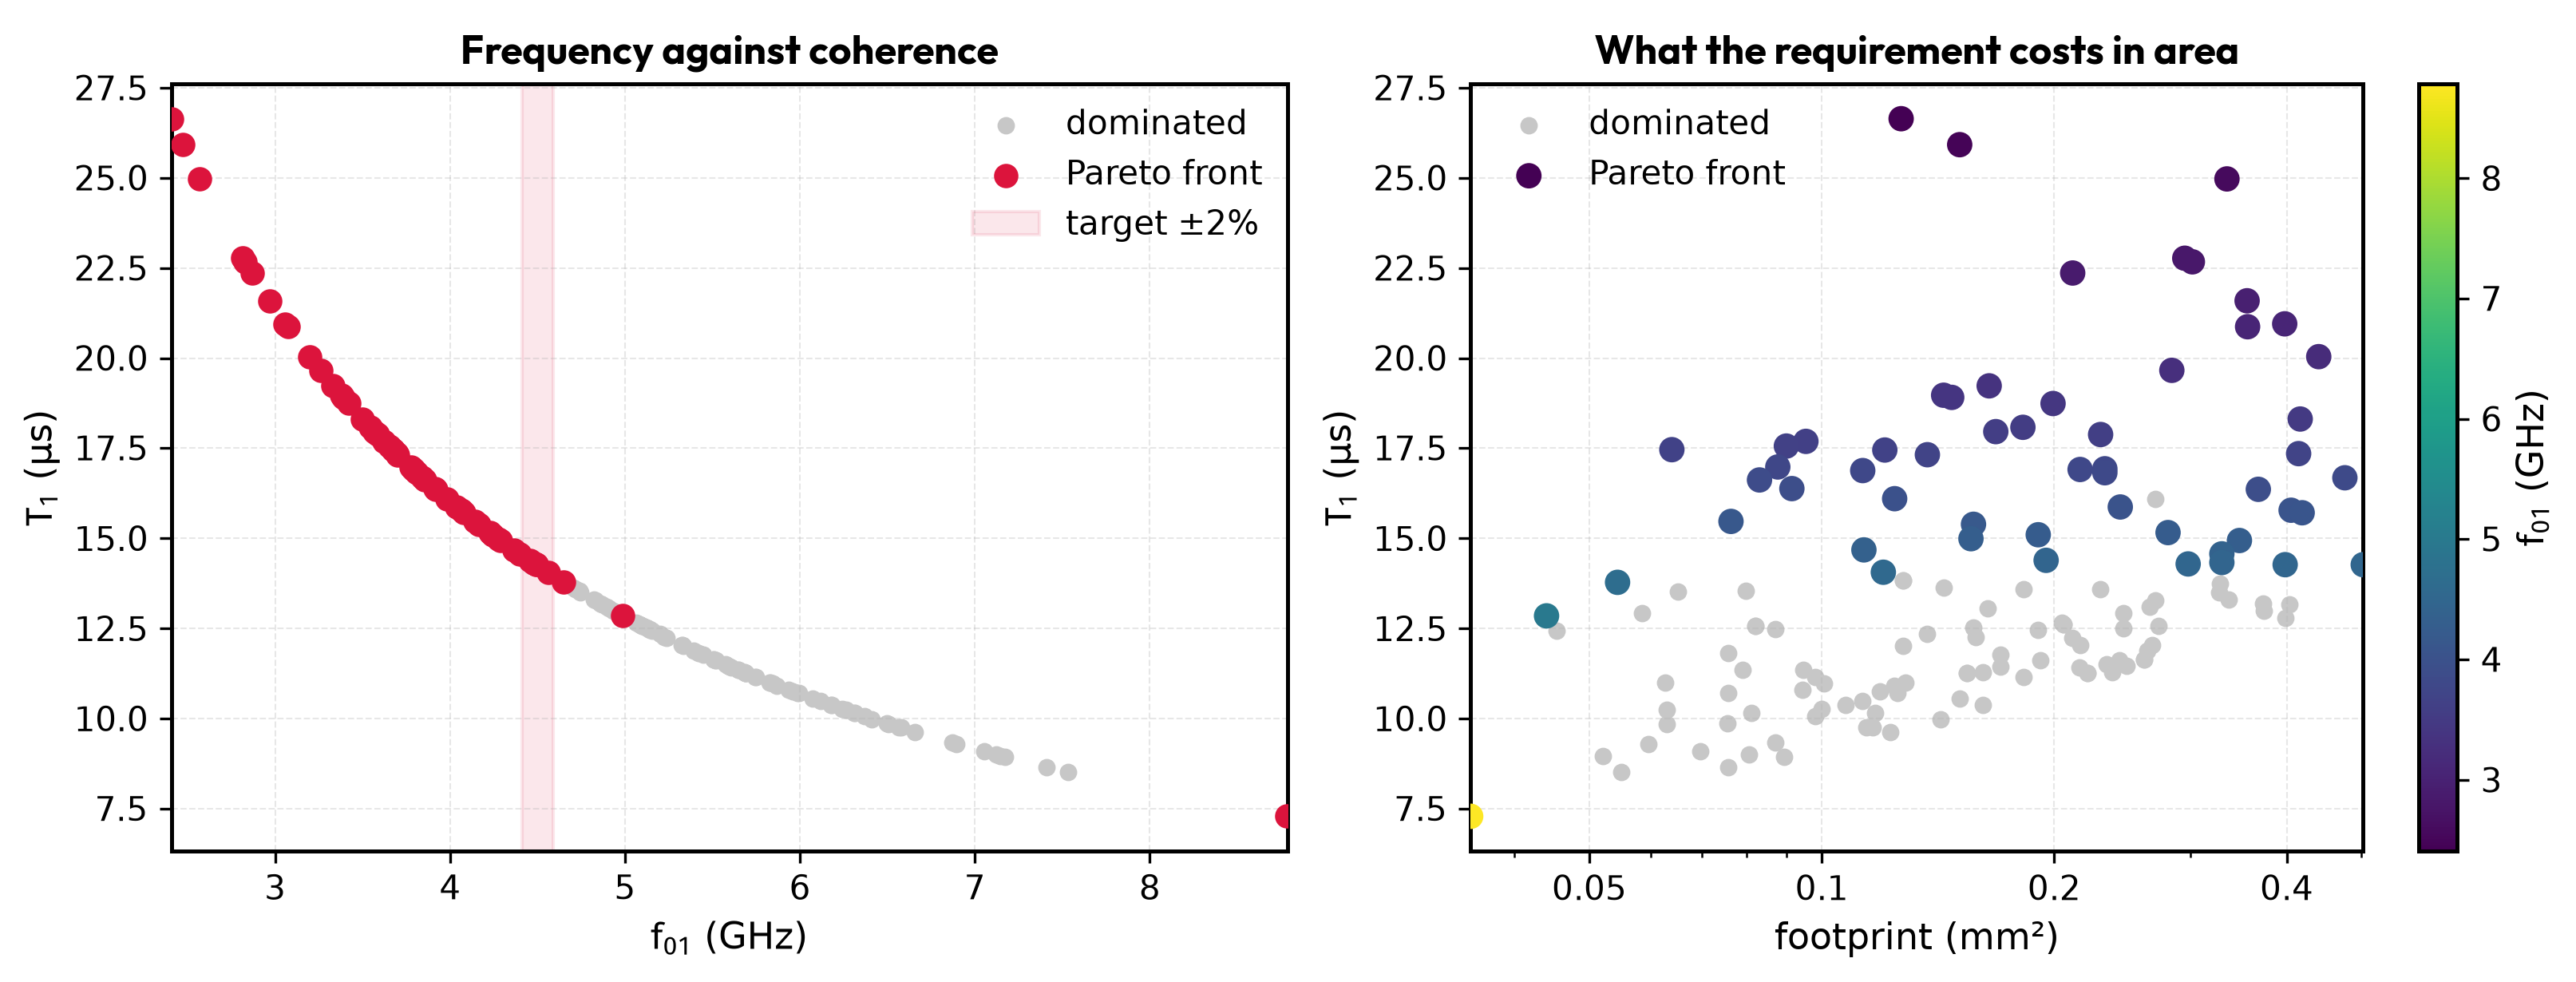

,pad_width,pad_height,pad_gap,f01_ghz,T1_us,footprint_mm2
103,109.62,577.91,13.70,2.408,26.64,0.127
112,169.53,444.96,13.09,2.473,25.92,0.151
55,273.14,612.80,20.65,2.570,24.97,0.335
17,229.12,644.19,25.30,2.815,22.77,0.295
70,367.78,410.52,18.15,2.827,22.67,0.302
58,218.44,483.71,20.37,2.869,22.36,0.211
48,354.11,501.95,25.03,2.968,21.59,0.355
56,359.14,553.66,29.34,3.059,20.95,0.398
140,308.02,577.91,29.34,3.072,20.87,0.356
120,351.34,626.38,37.84,3.199,20.04,0.440


In [14]:
front = trials[on_front].sort_values("f01_ghz")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(
    trials["f01_ghz"],
    trials["T1_us"],
    color="0.78",
    s=18,
    label="dominated",
)
axes[0].scatter(
    front["f01_ghz"],
    front["T1_us"],
    color="crimson",
    s=40,
    zorder=3,
    label="Pareto front",
)
axes[0].axvspan(
    target_ghz * (1 - TOLERANCE_BAND),
    target_ghz * (1 + TOLERANCE_BAND),
    color="crimson",
    alpha=0.10,
    label=f"target ±{TOLERANCE_BAND:.0%}",
)
axes[0].set_xlabel("$f_{01}$ (GHz)")
axes[0].set_ylabel("$T_1$ (µs)")
axes[0].set_title("Frequency against coherence")
axes[0].legend()

axes[1].scatter(
    trials["footprint_mm2"],
    trials["T1_us"],
    color="0.78",
    s=18,
    label="dominated",
)
front_scatter = axes[1].scatter(
    front["footprint_mm2"],
    front["T1_us"],
    c=front["f01_ghz"],
    cmap="viridis",
    s=44,
    zorder=3,
    label="Pareto front",
)
axes[1].set_xscale("log")
# The footprint spans barely a decade, so the default log labels are minor
# ticks in scientific notation that run into each other.
axes[1].set_xticks([0.05, 0.1, 0.2, 0.4], labels=["0.05", "0.1", "0.2", "0.4"])
axes[1].xaxis.set_minor_formatter(NullFormatter())
axes[1].set_xlabel("footprint (mm²)")
axes[1].set_ylabel("$T_1$ (µs)")
axes[1].set_title("What the requirement costs in area")
axes[1].legend()
fig.colorbar(front_scatter, ax=axes[1], label="$f_{01}$ (GHz)")

fig.tight_layout()
plt.show()
plt.close(fig)

front[
    ["pad_width", "pad_height", "pad_gap", "f01_ghz", "T1_us", "footprint_mm2"]
].round(3)

### Which knob matters

Optuna's fANOVA importance ranks the parameters by how much they explain the
variance in $T_1$, using a random forest over the finished trials. The
answer here is not the answer {cite:p}`Savola2023` gives, and the reason is
instructive.

In this model $T_1 = Q_\mathrm{TLS}/(2\pi f_{01})$ with
$Q_\mathrm{TLS}$ effectively fixed, so a parameter matters exactly to
the extent that it moves the frequency, and the pad gap is by far the
strongest lever on that. The thesis, with the interfaces in the model, finds
pad height instead: with $Q$ free to move, the parameter that adds
shunt capacitance without crowding field into a lossy interface wins on
coherence rather than on frequency.

So the ranking below is a statement about this loss model as much as about the
device. The second panel, importance for the frequency error rather than for
$T_1$, separates the two: it ranks the same parameters by how well they
pin the design to its target band, which is a property of the device rather
than of the model.

[I 2026-09-23 01:07:02,531] A new study created in memory with name: transmon-layout-reloaded


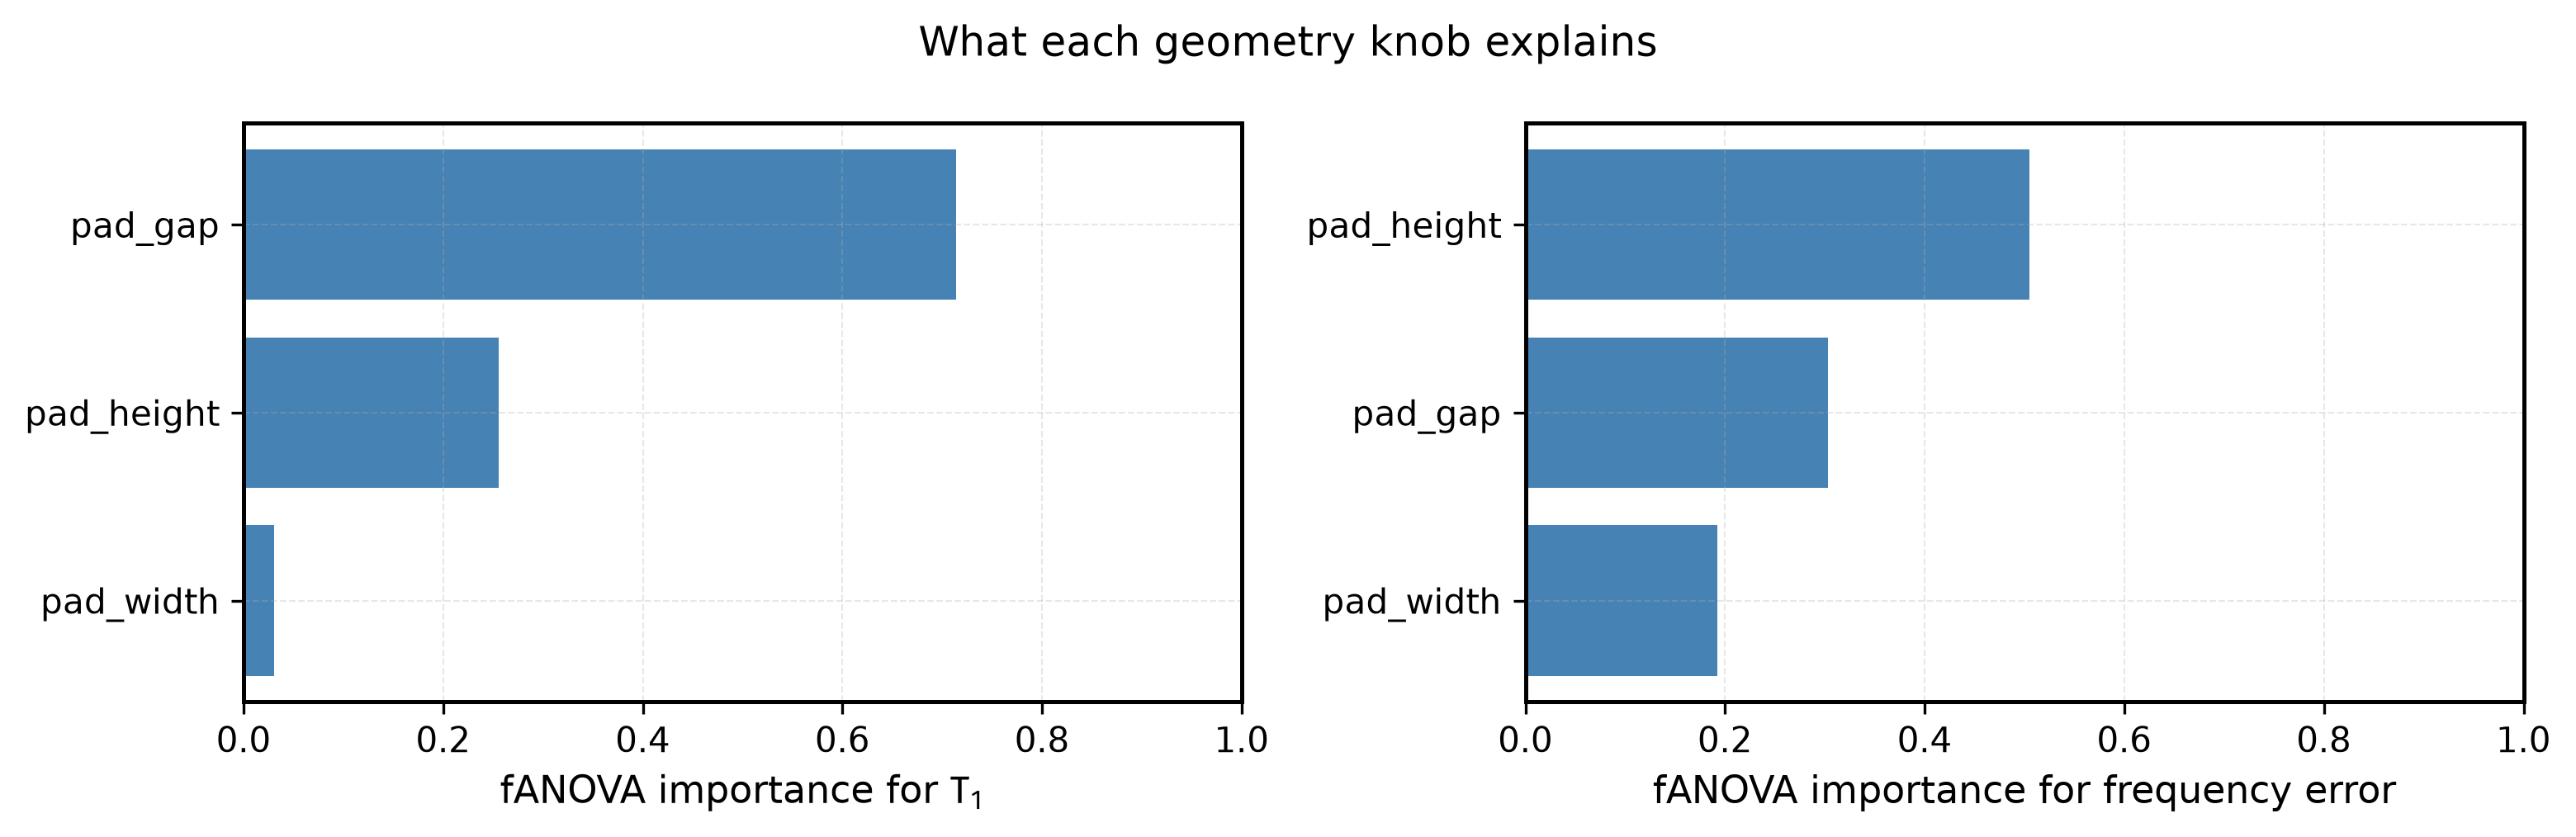

,$T_1$,frequency error
pad_gap,0.714,0.303
pad_height,0.255,0.505
pad_width,0.031,0.192


In [15]:
def study_from_trials(trials: pd.DataFrame) -> optuna.Study:
    """Rebuild an Optuna study from a finished trial table.

    Lets the importance analysis below run from the embedded results, without
    the sampler or the solver.

    Args:
        trials: The finished trial table.

    Returns:
        A study holding one trial per row, with the same distributions the
        sampler used.
    """
    from optuna import distributions

    bounds = {
        "pad_width": PAD_WIDTH_RANGE,
        "pad_height": PAD_HEIGHT_RANGE,
        "pad_gap": PAD_GAP_RANGE,
    }
    rebuilt = optuna.create_study(
        study_name="transmon-layout-reloaded",
        directions=["minimize", "maximize", "minimize"],
    )
    for row in trials.itertuples():
        rebuilt.add_trial(
            optuna.trial.create_trial(
                params={name: getattr(row, name) for name in bounds},
                distributions={
                    name: distributions.FloatDistribution(*limits, step=LAYOUT_GRID_UM)
                    for name, limits in bounds.items()
                },
                values=[
                    abs(row.f01 - F_TARGET) / F_TARGET,
                    row.T1,
                    row.footprint_mm2,
                ],
            )
        )
    return rebuilt


front_study = study or study_from_trials(trials)
importance = {
    label: optuna.importance.get_param_importances(
        front_study,
        # An Optuna trial's values, not a DataFrame column.
        target=lambda trial, index=index: trial.values[index],  # ruff: ignore[pandas-use-of-dot-values]
    )
    for label, index in (("$T_1$", 1), ("frequency error", 0))
}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), sharex=True)
for axis, (label, values) in zip(axes, importance.items(), strict=True):
    axis.barh(list(values)[::-1], list(values.values())[::-1], color="steelblue")
    axis.set_xlabel(f"fANOVA importance for {label}")
    axis.set_xlim(0, 1)
fig.suptitle("What each geometry knob explains")
fig.tight_layout()
plt.show()
plt.close(fig)

pd.DataFrame(importance).round(3)

The same question, asked of the sweep rather than of a fitted model: plot each
parameter against each objective. A parameter the objective responds to shows
a trend; one it ignores shows a cloud. Colouring by the third parameter is
what separates "this parameter does nothing" from "this parameter only matters
in combination with another".

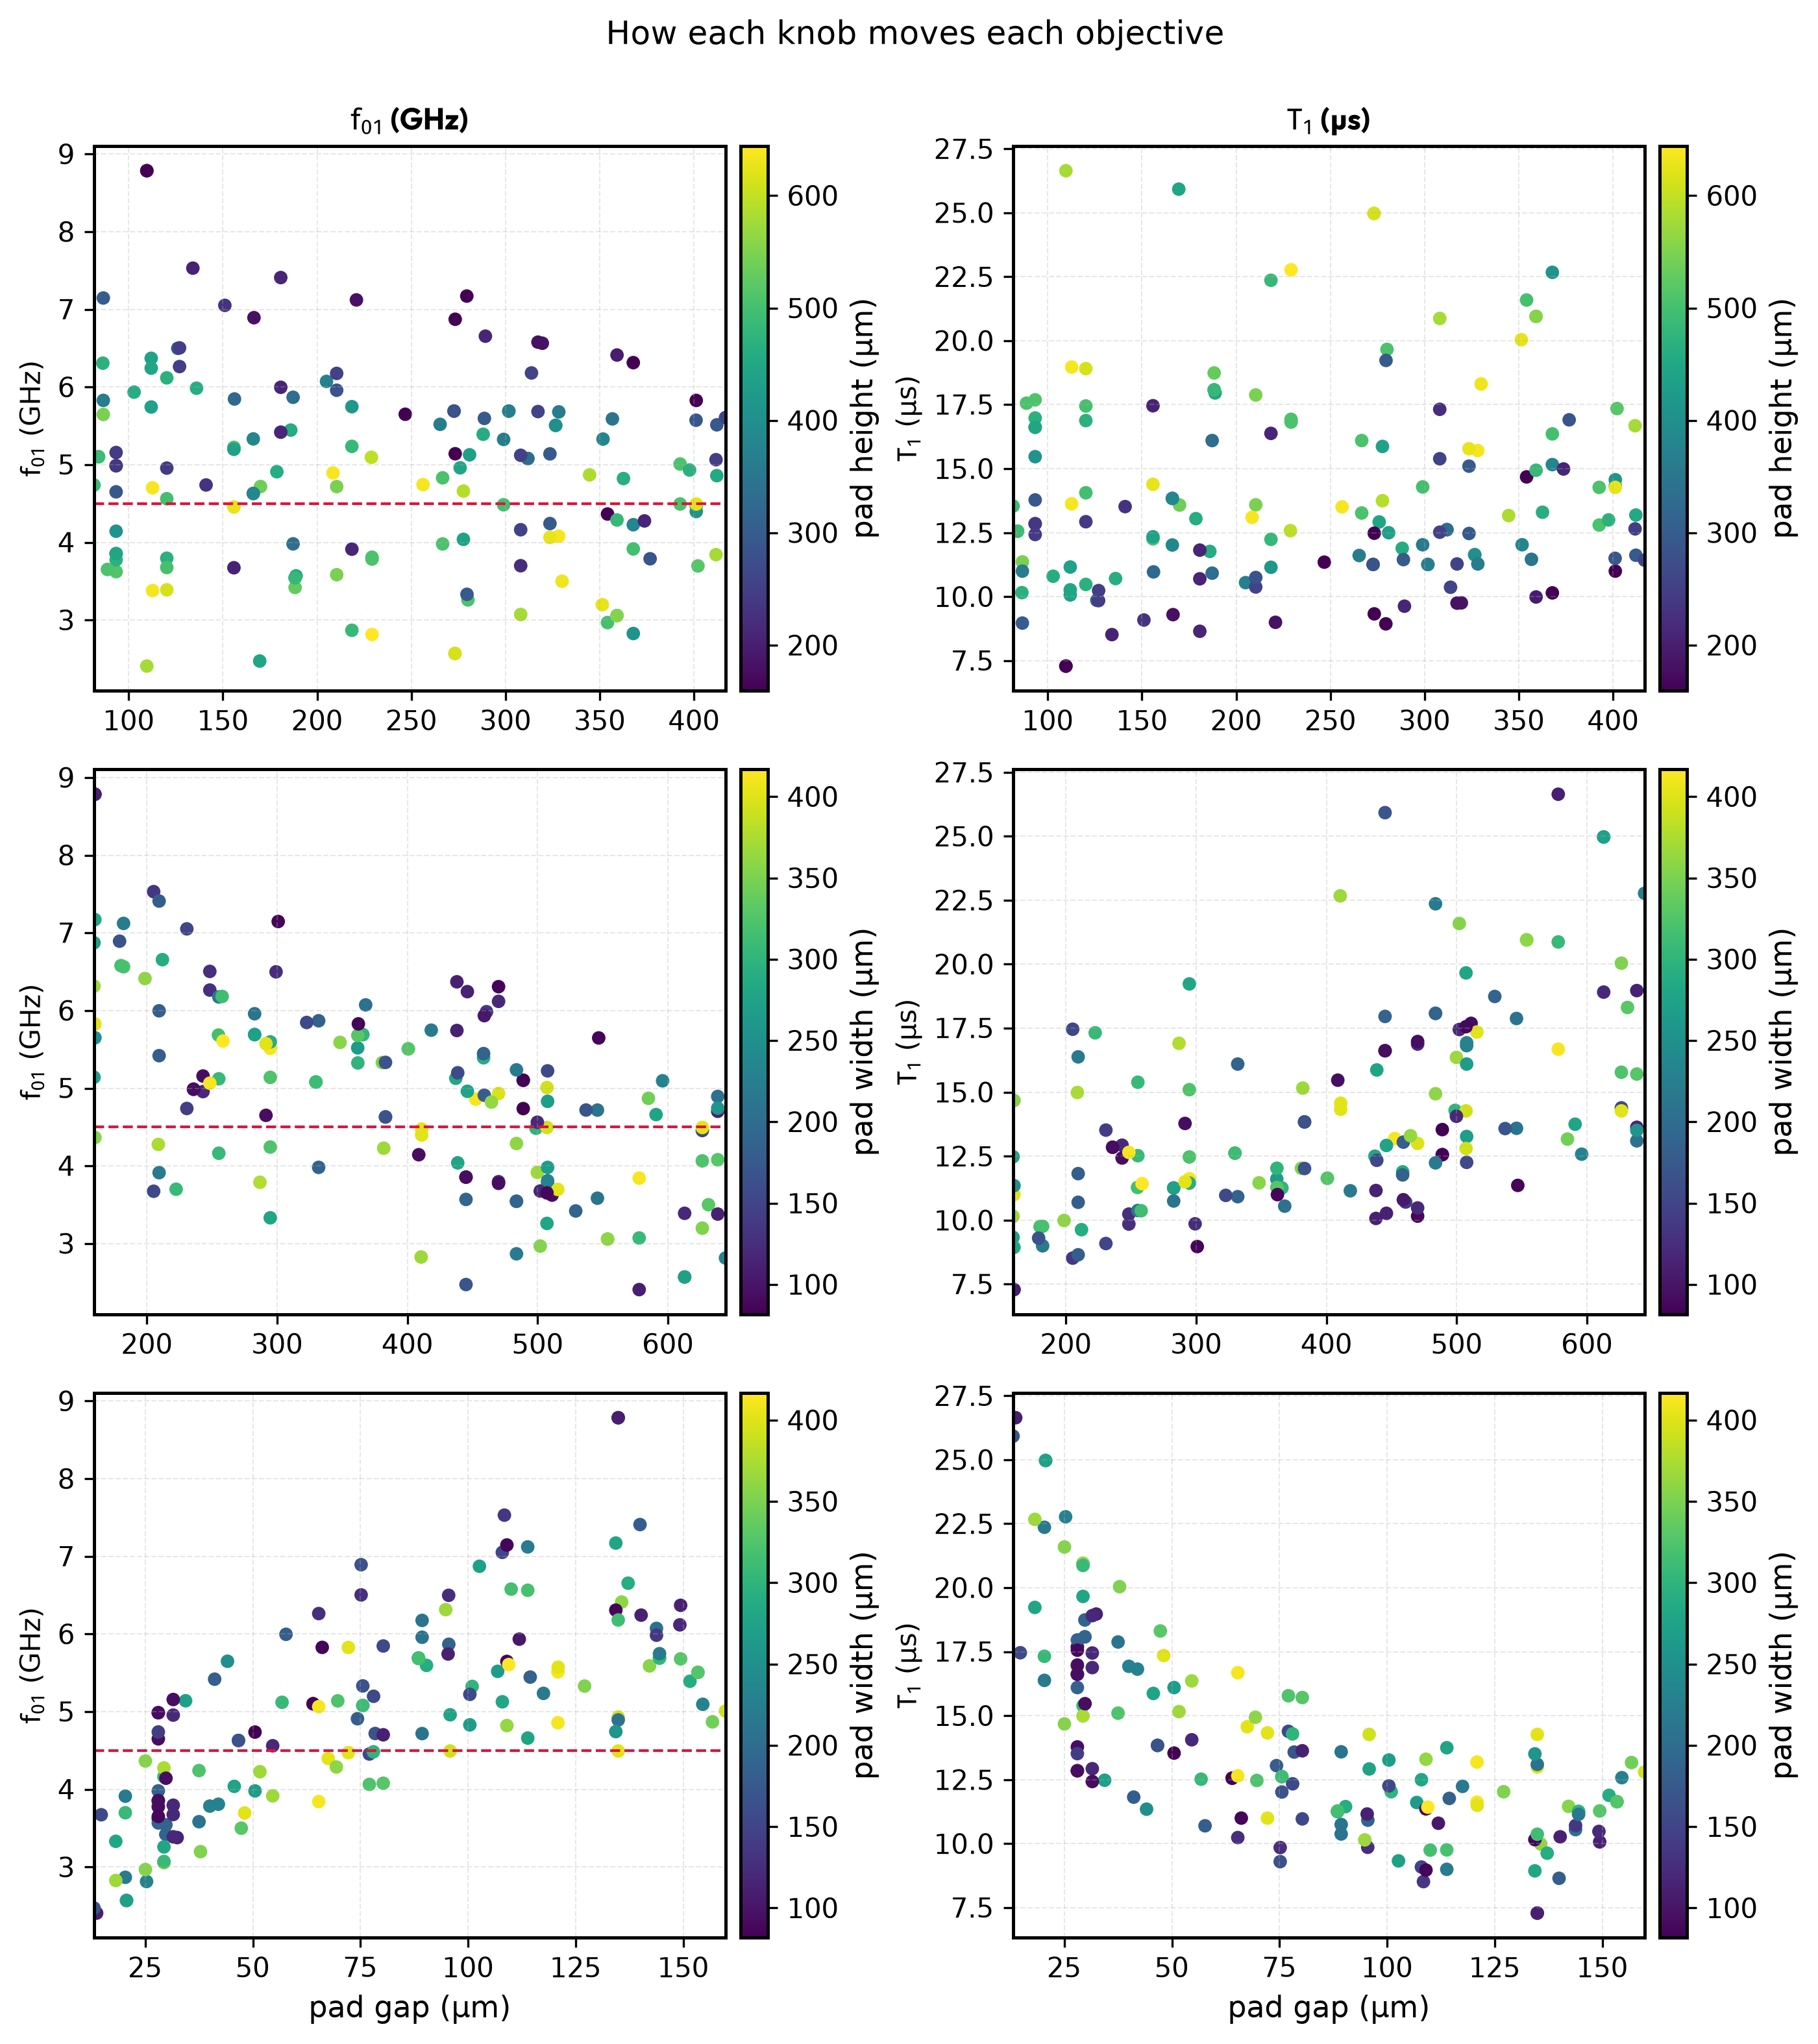

In [16]:
fig, axes = plt.subplots(
    len(PARAMETERS),
    2,
    figsize=(9.5, 10.5),
    # Not sharex: each row is a different parameter with its own range. The
    # objective is what repeats down a column, so that is what can be shared.
    sharey="col",
)

for row, (name, (_, label)) in enumerate(frames.items()):
    others = [other for other in PARAMETERS if other != name]
    colour_by = others[0]
    for column, (objective, objective_label) in enumerate((
        ("f01_ghz", "$f_{01}$ (GHz)"),
        ("T1_us", "$T_1$ (µs)"),
    )):
        axis = axes[row, column]
        points = axis.scatter(
            trials[name],
            trials[objective],
            c=trials[colour_by],
            cmap="viridis",
            s=16,
        )
        if column == 0:
            axis.axhline(target_ghz, color="crimson", ls="--", lw=1.0)
        if row == 0:
            axis.set_ylabel(objective_label, fontsize=10)
            axis.set_title(objective_label, fontsize=11)
        else:
            axis.set_ylabel(objective_label, fontsize=10)
        if row == len(PARAMETERS) - 1:
            axis.set_xlabel(label)
        fig.colorbar(points, ax=axis, label=frames[colour_by][1], pad=0.02)

fig.suptitle("How each knob moves each objective", y=0.995)
fig.tight_layout()
plt.show()
plt.close(fig)

### Reading the sweep as a whole

Parallel coordinates put every trial on one line, one axis per parameter and
per objective, which is how the trade-off becomes visible at once: the trials
that reach high $T_1$ are the ones whose lines sit low on the frequency
axis. Colouring by $T_1$ makes the front visible as a band rather than a
scatter of points.

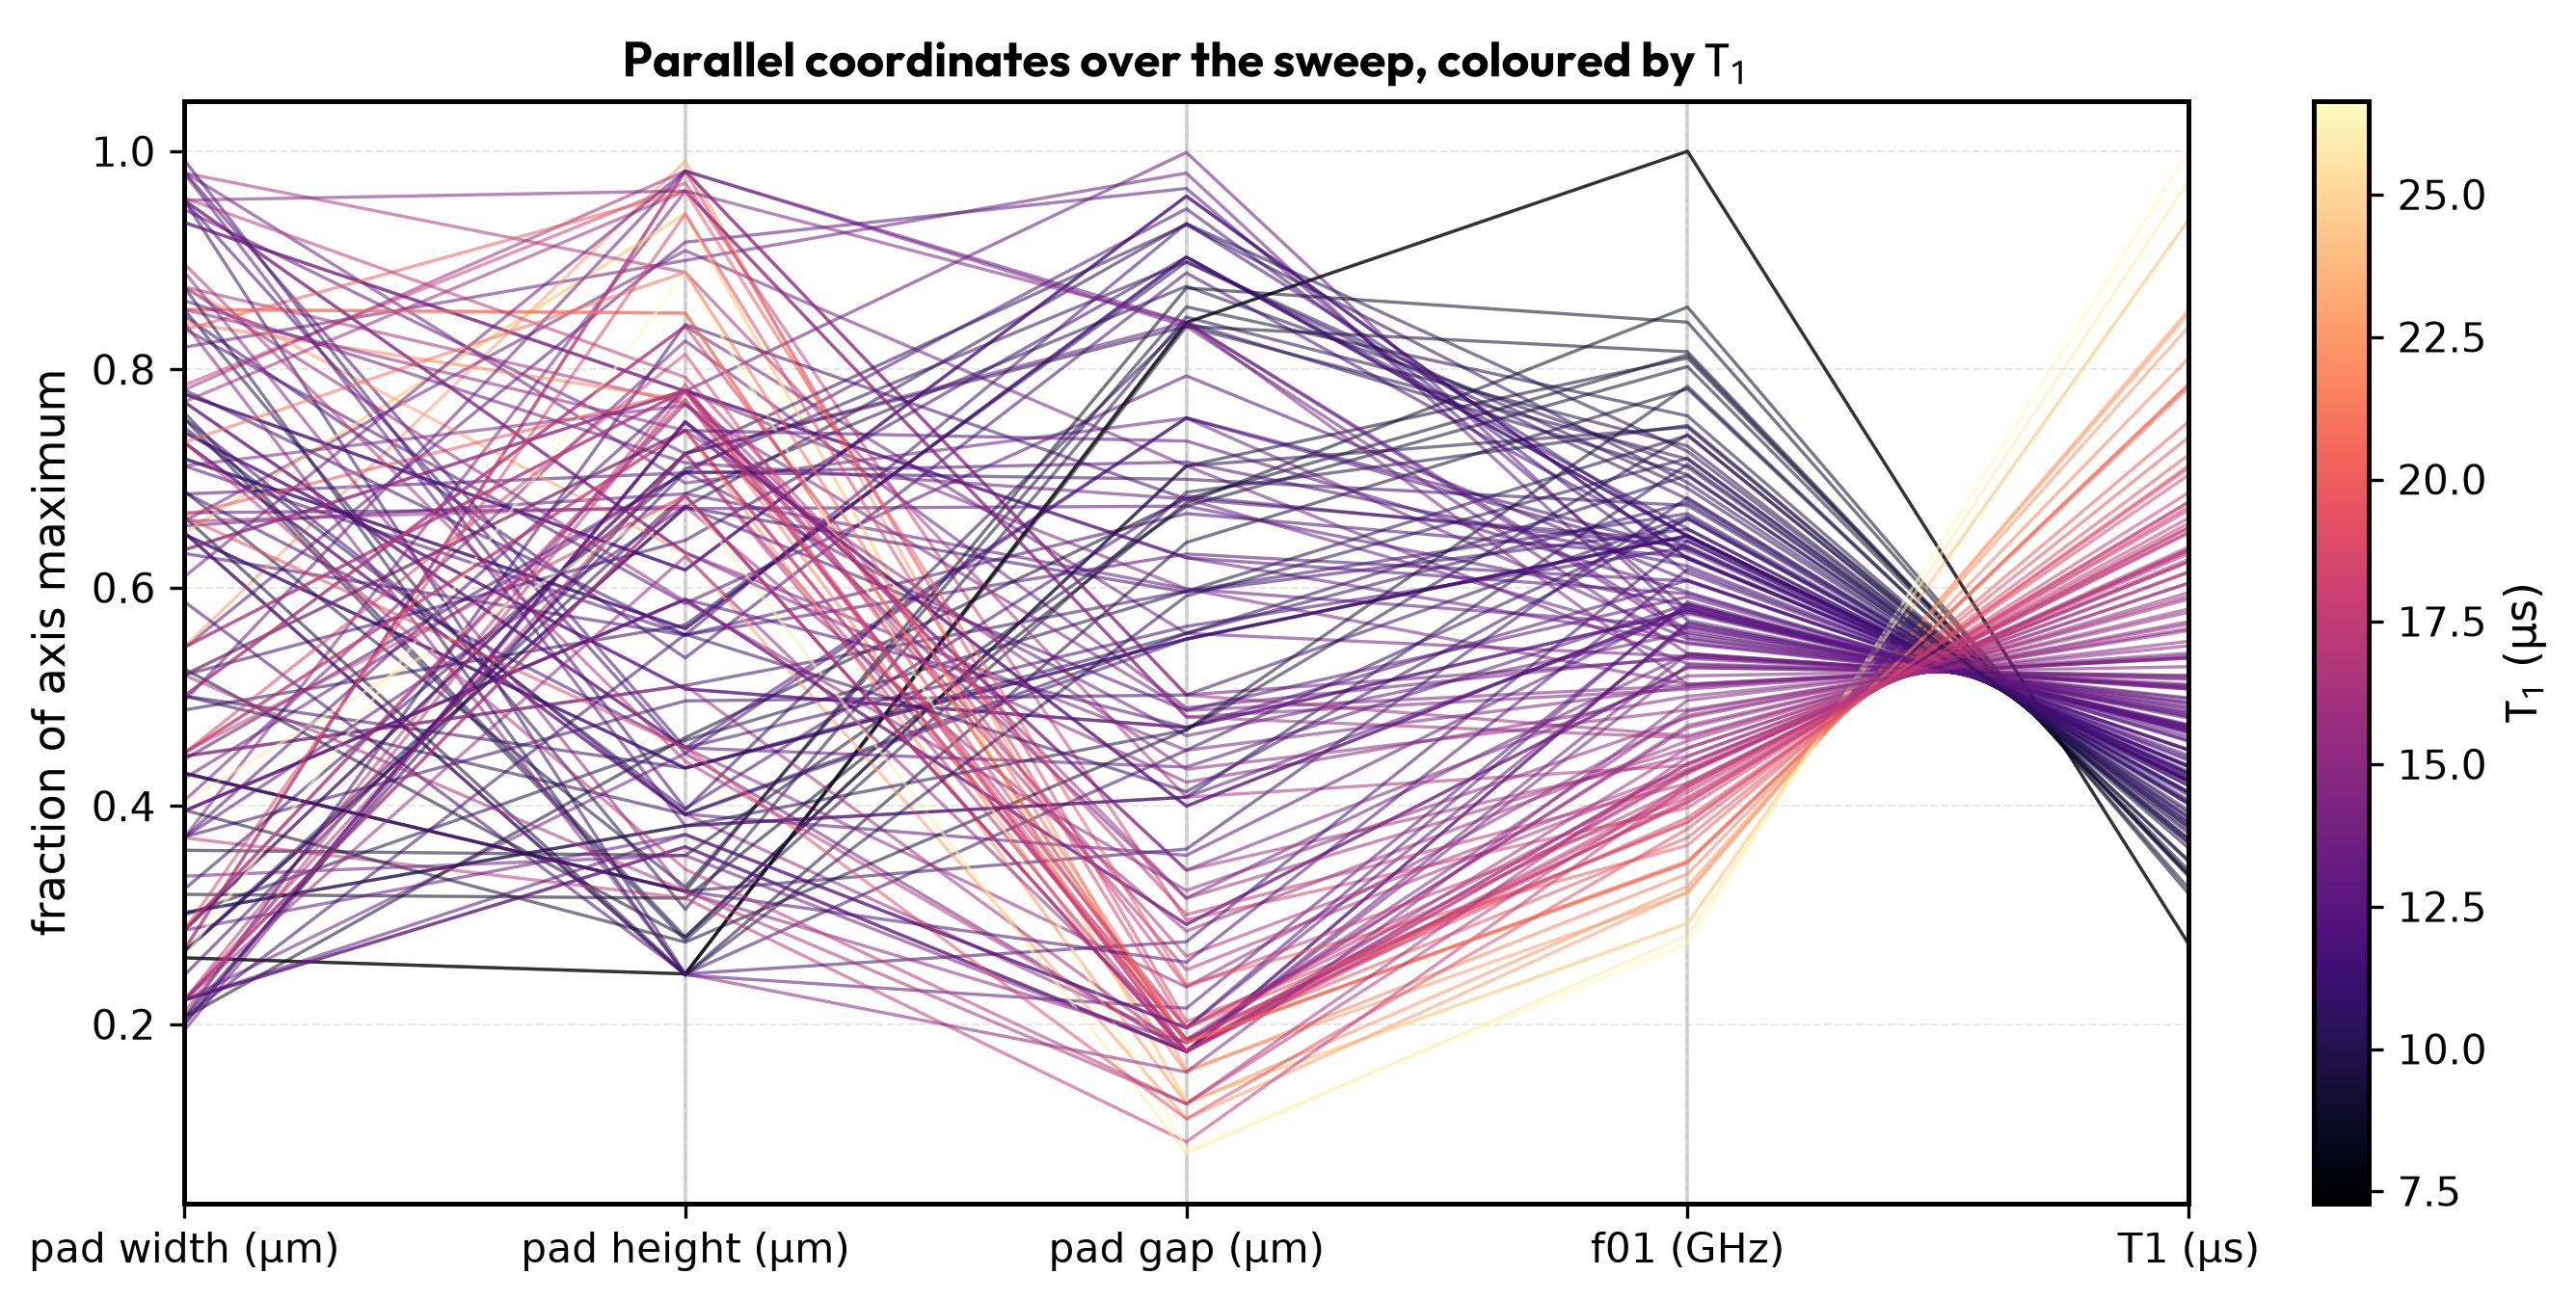

In [17]:
parallel_axes = [
    *PARAMETERS,
    "f01_ghz",
    "T1_us",
]
upper = {
    "pad_width": PAD_WIDTH_RANGE[1],
    "pad_height": PAD_HEIGHT_RANGE[1],
    "pad_gap": PAD_GAP_RANGE[1],
}
upper["f01_ghz"] = float(trials["f01_ghz"].max())
upper["T1_us"] = float(trials["T1_us"].max())

fig, ax = plt.subplots(figsize=(9.5, 4.6))
colour = trials["T1_us"].to_numpy()
normaliser = plt.Normalize(colour.min(), colour.max())
for row in trials.itertuples():
    values = [getattr(row, name) / upper[name] for name in parallel_axes]
    ax.plot(
        range(len(parallel_axes)),
        values,
        color=plt.cm.magma(normaliser(row.T1_us)),
        alpha=0.55,
        lw=0.8,
    )

for index in range(len(parallel_axes)):
    ax.axvline(index, color="0.85", lw=1.0, zorder=0)
ax.set_xticks(range(len(parallel_axes)))
ax.set_xticklabels([
    frames[name][1]
    if name in frames
    else name.replace("_ghz", " (GHz)").replace("_us", " (µs)")
    for name in parallel_axes
])
ax.set_ylabel("fraction of axis maximum")
ax.set_title("Parallel coordinates over the sweep, coloured by $T_1$")
fig.colorbar(plt.cm.ScalarMappable(normaliser, plt.cm.magma), ax=ax, label="$T_1$ (µs)")
fig.tight_layout()
plt.show()
plt.close(fig)

### The geometry to build

A multi-objective study does not return a single answer, so the last step is
to turn the front into a decision. The frequency is a requirement rather than
a preference, so it is applied as a constraint first: only trials inside the
band are candidates. What is left is a genuine choice between area and
coherence, and the rule below states the trade explicitly: take the smallest
footprint whose $T_1$ is within
`T1_SLACK` of the best in the band, rather than buying the last few
percent of coherence with several times the silicon.

In [18]:
on_target = trials[np.abs(trials["f01_ghz"] - target_ghz) < TOLERANCE_BAND * target_ghz]
if on_target.empty:
    # A short or unlucky sweep can miss the band. Fall back to the closest
    # trial rather than discarding a finished batch, but say so.
    logger.warning(
        f"no trial within {TOLERANCE_BAND:.0%} of {target_ghz} GHz; "
        "falling back to the closest trial"
    )
    on_target = trials.assign(
        distance=(trials["f01_ghz"] - target_ghz).abs()
    ).nsmallest(1, "distance")

best_t1 = on_target["T1_us"].max()
# The smallest qubit that is essentially as good as the best one on coherence.
affordable = on_target[on_target["T1_us"] >= best_t1 * (1 - T1_SLACK)]
best = affordable.loc[affordable["footprint_mm2"].idxmin()]
best_in_band = on_target.loc[on_target["T1_us"].idxmax()]

logger.info(f"{len(on_target)} trials within {TOLERANCE_BAND:.0%} of {target_ghz} GHz")
logger.info(
    f"chosen trial {int(best['trial'])}: pads "
    f"{best['pad_width']:.0f} x {best['pad_height']:.0f} µm, "
    f"gap {best['pad_gap']:.1f} µm"
)
logger.info(
    f"  f01 = {best['f01_ghz']:.4f} GHz "
    f"({(best['f01_ghz'] - target_ghz) / target_ghz * 100:+.2f} % off target), "
    f"T1 = {best['T1_us']:.2f} µs, "
    f"footprint = {best['footprint_mm2']:.3f} mm², "
    f"Q = {best['quality_factor']:.3e}"
)
logger.info(
    f"  largest T1 in the band is {best_t1:.2f} µs at "
    f"{best_in_band['footprint_mm2']:.3f} mm², so this costs "
    f"{(best['T1_us'] / best_t1 - 1) * 100:+.1f} % of T1 for "
    f"{best_in_band['footprint_mm2'] / best['footprint_mm2']:.1f}x less area"
)

2026-09-23 01:07:04.159 | INFO     | __main__:<module>:19 - 6 trials within 2% of 4.5 GHz


2026-09-23 01:07:04.159 | INFO     | __main__:<module>:20 - chosen trial 123: pads 120 x 500 µm, gap 54.6 µm


2026-09-23 01:07:04.159 | INFO     | __main__:<module>:25 -   f01 = 4.5624 GHz (+1.39 % off target), T1 = 14.06 µs, footprint = 0.120 mm², Q = 4.030e+05


2026-09-23 01:07:04.160 | INFO     | __main__:<module>:32 -   largest T1 in the band is 14.39 µs at 0.195 mm², so this costs -2.3 % of T1 for 1.6x less area


In [19]:
best_layout = Layout(
    pad_width=float(best["pad_width"]),
    pad_height=float(best["pad_height"]),
    pad_gap=float(best["pad_gap"]),
)
best_layout

Layout(pad_width=120.21, pad_height=499.74, pad_gap=54.61)

### Where the field sits

The participation ratios are the part of the result that a single number
cannot carry, because they say *why* one geometry loses more than another. The
substrate holds the overwhelming majority of the electric energy in every
trial, which is the geometric fact behind the caveat above: the double-pad
capacitor stores its field in the silicon, so the metal-air interface that
dominates real device loss is a small correction to a large substrate
participation rather than the other way round.

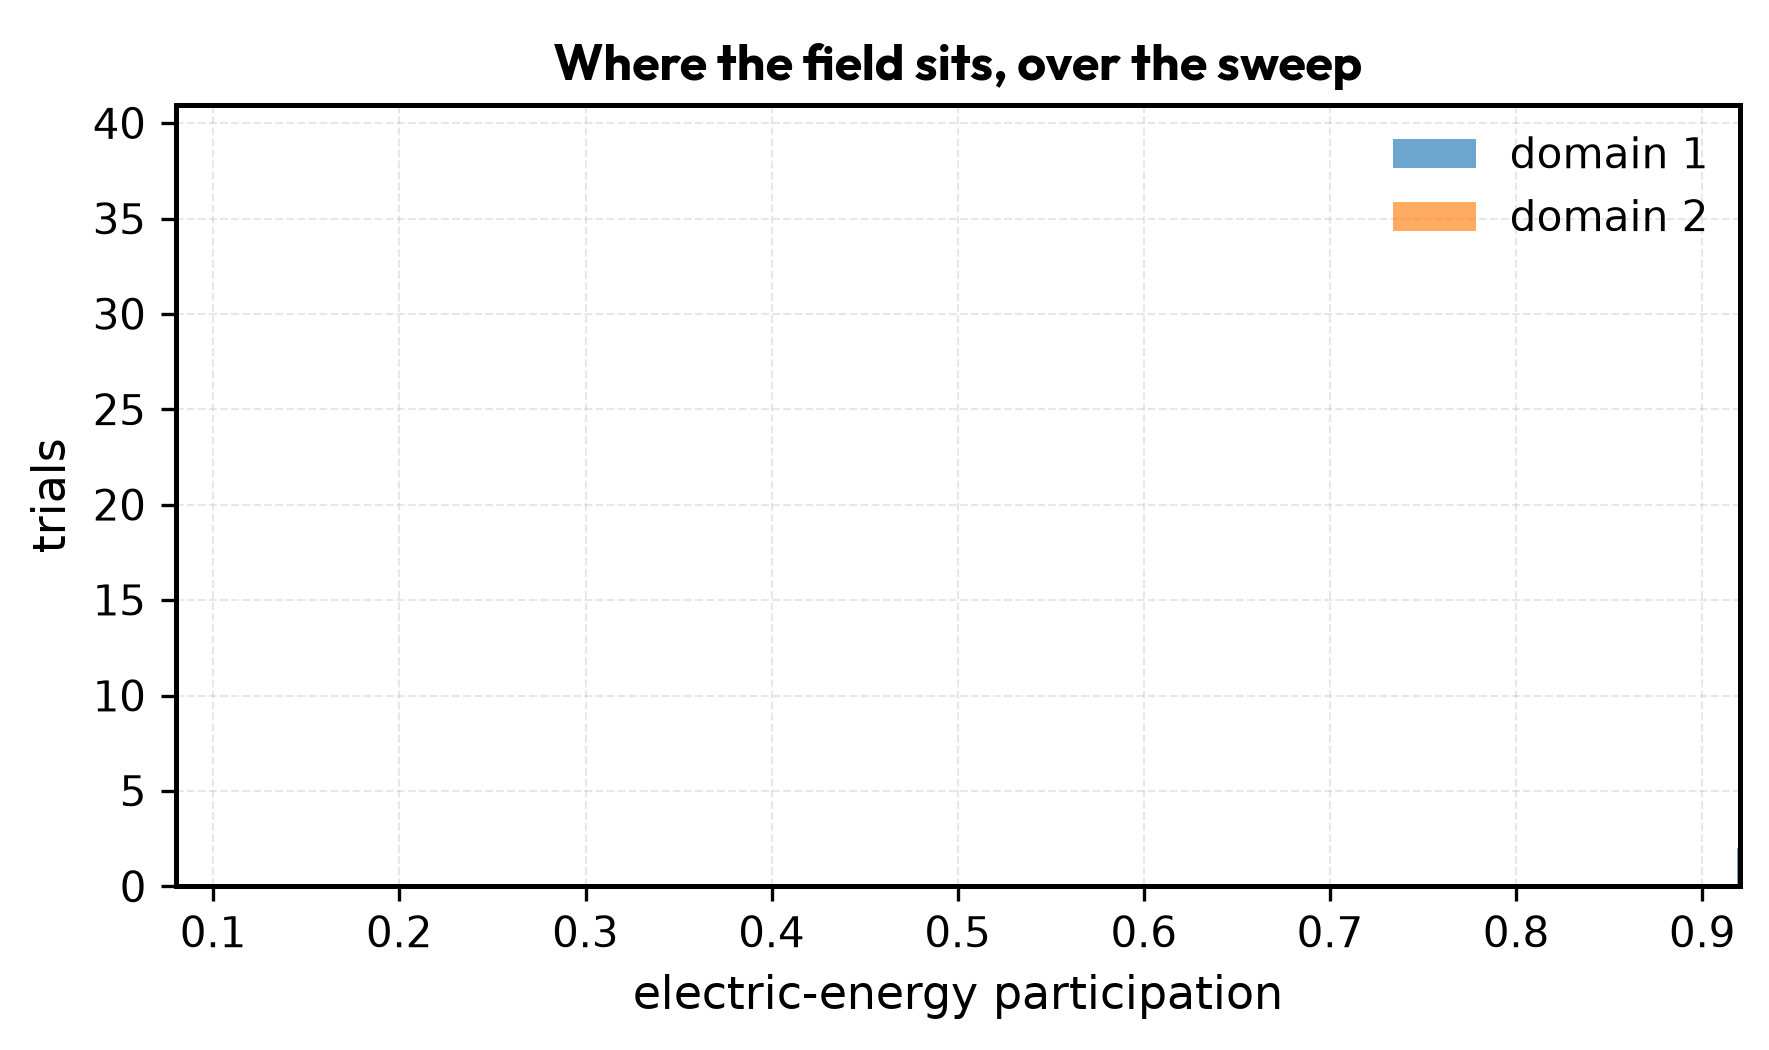

In [20]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
for index in sorted(
    column for column in trials.columns if column.startswith("participation_domain")
):
    ax.hist(
        trials[index],
        bins=24,
        alpha=0.65,
        label=f"domain {index.removeprefix('participation_domain')}",
    )
ax.set_xlabel("electric-energy participation")
ax.set_ylabel("trials")
ax.set_title("Where the field sits, over the sweep")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

(slurm-launcher)=
## Running the study on a Slurm cluster

On a shared cluster the work goes out as **one job per trial**, which is what
`qpdk.simulation.SlurmCluster` renders: an `sbatch` script taking a parameter
file as its argument, submitted once per trial. Each job asks for
`solver_cores` cores, so it starts wherever the scheduler finds room, and a
scheduler has no trouble with a few hundred of them. Nothing is batched: the
driver keeps `MAX_IN_FLIGHT` of them alive and replaces each as it finishes.

The alternative, hosting a Ray cluster inside one multi-node allocation, is
rendered by the same object and is a better fit when the job owns its nodes
rather than sharing them; the manual `ray start` arrangement it uses is the
one from the
[Ray on Slurm guide](https://docs.ray.io/en/latest/cluster/vms/user-guides/community/slurm.html).

Two kinds of job are involved, and it is worth keeping them straight:

- the **driver**, a one-core job that asks Optuna for trials, submits them,
  and tells Optuna what comes back. It runs this notebook and owns the study,
  so it is the job whose log tells you how the sweep is going.
- the **trial jobs**, one per geometry, where the solving actually happens.
  Each writes its own log under `log_dir`.

Submitting the driver as a job rather than running it interactively matters for
anything long: a study that takes hours should not be tied to a login session.

The values above are placeholders, and the comments say what each one has to
satisfy rather than which cluster it came from. Point them at a real site
without editing the notebook by setting the matching `QPDK_*` variables
(`QPDK_PARTITION`, `QPDK_SCRATCH`, `QPDK_SIF`, `QPDK_SETUP`,
`QPDK_SOLVER_CORES`, `QPDK_MEM_PER_TASK`, `QPDK_TIME_LIMIT`) before running
it; `site()` reads them and falls back to the placeholder.

In [21]:
driver = (
    f"export QPDK_RUN_OPTIMIZATION=1 "
    f"QPDK_N_TRIALS={N_TRIALS} QPDK_MAX_IN_FLIGHT={MAX_IN_FLIGHT} "
    f"QPDK_PALACE_SIF={PALACE_SIF} QPDK_TRIALS_CSV=trials.csv\n"
    "uv run --frozen python notebooks/src/palace_batched_qubit_optimization.py"
)

driver_path = cluster.write_driver_script("build/submit_driver.sbatch", driver)
logger.info(f"wrote {driver_path}")
print(driver_path.read_text())

2026-09-23 01:07:04.255 | INFO     | __main__:<module>:9 - wrote build/submit_driver.sbatch


#!/bin/bash
#SBATCH --job-name=qpdk-opt-driver
#SBATCH --partition=batch
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G
#SBATCH --time=24:00:00
#SBATCH --output=slurm-logs/qpdk-opt-driver-%j.out

set -euo pipefail
# Slurm runs a spool copy of the batch script, so $0 is not the submit
# directory. It sets SLURM_SUBMIT_DIR for jobs submitted from a login node but
# not always for ones submitted from a compute node, and a plain `cd ""` would
# quietly leave the job in $HOME, so fall back to where it already is. Commands
# passed in should use absolute paths all the same.
cd "${SLURM_SUBMIT_DIR:-$PWD}"

# Exported before the setup snippet, which may expand it; `set -u` would
# otherwise abort the job here.
export QPDK_SCRATCH="/scratch/$USER/palace-optimization"
export MPLBACKEND=Agg


module load python 2>/dev/null || true
export UV_CACHE_DIR="$QPDK_SCRATCH/uv-cache"
export UV_PYTHON_INSTALL_DIR="$QPDK_SCRATCH/uv-python"
export PATH="$HOME/.local/bin:$PATH

The Ray arrangement is the same object rendering a different script: one
allocation, a Ray head and workers started across its nodes, and the driver on
the head selecting `ray_executor`. It suits a job that owns its nodes; the
one-job-per-trial path above suits a shared cluster, because the jobs queue
independently.

In [22]:
ray_driver = (
    f"export QPDK_RUN_OPTIMIZATION=1 QPDK_EXECUTOR=ray "
    f"QPDK_N_TRIALS={N_TRIALS} QPDK_MAX_IN_FLIGHT={MAX_IN_FLIGHT} "
    f"QPDK_PALACE_SIF={PALACE_SIF} QPDK_TRIALS_CSV=trials.csv\n"
    "uv run --frozen python notebooks/src/palace_batched_qubit_optimization.py"
)
ray_path = cluster.write_sbatch_script("build/submit_ray.sbatch", ray_driver)
logger.info(f"wrote {ray_path}")

2026-09-23 01:07:04.259 | INFO     | __main__:<module>:8 - wrote build/submit_ray.sbatch


Submitting is then `sbatch build/submit_driver.sbatch`, and from there the
driver's log is the one to watch: it reports each trial as it lands, how many
back, how many failed, and the best design so far. Because the driver writes
its log as it goes rather than at the end, `tail -f` on it is enough to follow
a study that runs for hours.

```bash
sbatch build/submit_driver.sbatch
tail -f slurm-logs/$QPDK_JOB_NAME-driver-*.out   # qpdk-opt-driver-*.out by default
```

Two things are worth checking before a long run:

- **Reproduce a known result first.** Submit a batch of one or two trials and
  compare them against the same geometry solved elsewhere, or against the
  inductance-scaling check above. A different MPI build, BLAS, or node
  instruction set can perturb a solve in ways that look like findings.
- **Size the wall clock from a measured trial, not a guess.** A coarse solve is
  seconds, but the cost rises steeply with mesh refinement and mode count, and
  a job that runs out of time writes nothing. `solver_cores` and
  `MAX_IN_FLIGHT` are the other two knobs: raising the first makes each solve
  finish sooner on a bigger allocation, while the second sets how much of the
  cluster the sweep takes at once.

## Summary

- A transmon layout sweep against three objectives, target frequency,
  relaxation time and pad footprint, driven by Optuna over independent
  Palace eigenmode solves dispatched as individual Slurm jobs.
- The first two come from the same solve: the frequency from the eigenmode,
  $T_1$ from $Q_\mathrm{TLS}/(2\pi f_{01})$ with
  $Q_\mathrm{TLS}$ reconstructed from the energy participation ratios
  that Palace reports for the lossy domains. The footprint comes from the
  geometry, at no extra cost.
- Frequency and coherence conflict through $f_{01}$, and footprint
  conflicts with both, so the useful output is the Pareto front rather than a
  single optimum, and the batch is what makes the front affordable. In this
  sweep the area is where the freedom is: designs inside the target band span
  a factor of four in footprint for a few percent of $T_1$.
- The `Q` obtained this way is the substrate-limited quality factor. The
  interfaces that dominate TLS loss in hardware are nanometres thick and are
  not resolved at this mesh scale, which is the main thing to improve before
  reading $T_1$ as an absolute prediction.
- Submitting each trial as its own small Slurm job, rather than hosting a Ray
  cluster inside one allocation, is what makes the sweep cheap on a shared
  machine: a job sized at `solver_cores` starts wherever there is room, so
  nothing waits for a whole node. Keeping a fixed number in flight rather than
  evaluating fixed batches is what keeps them all busy, since no trial waits
  on the slowest member of its batch.

## References

```{bibliography}
:filter: docname in docnames
```